In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = "/content/drive/MyDrive/acdc"
SRC = os.path.join(BASE, "training")
DST_IMG = os.path.join(BASE, "data/imagesTr")
DST_LAB = os.path.join(BASE, "data/labelsTr")

os.makedirs(DST_IMG, exist_ok=True)
os.makedirs(DST_LAB, exist_ok=True)

print("✅ Directory structure ready!")
print("SRC:", SRC)
print("DST_IMG:", DST_IMG)
print("DST_LAB:", DST_LAB)


Mounted at /content/drive
✅ Directory structure ready!
SRC: /content/drive/MyDrive/acdc/training
DST_IMG: /content/drive/MyDrive/acdc/data/imagesTr
DST_LAB: /content/drive/MyDrive/acdc/data/labelsTr


In [ ]:
import os, glob, shutil, re

SRC = "/content/drive/MyDrive/acdc/training"
DST_IMG = "/content/drive/MyDrive/acdc/data/imagesTr"
DST_LAB = "/content/drive/MyDrive/acdc/data/labelsTr"

os.makedirs(DST_IMG, exist_ok=True)
os.makedirs(DST_LAB, exist_ok=True)

patients = sorted(glob.glob(os.path.join(SRC, "patient*")))
print(f"Found {len(patients)} patients")

for p in patients:
    info_path = os.path.join(p, "Info.cfg")
    if not os.path.exists(info_path):
        print(f"⚠️ Missing Info.cfg for {p}")
        continue

    ed, es = None, None
    with open(info_path) as f:
        for line in f:
            line = line.strip()
            # Match both "ED: 1" or "ED = 1", case-insensitive
            if re.match(r"(?i)^ED\s*[:=]\s*\d+", line):
                ed = int(re.findall(r"\d+", line)[0])
            elif re.match(r"(?i)^ES\s*[:=]\s*\d+", line):
                es = int(re.findall(r"\d+", line)[0])

    if ed is None or es is None:
        print(f"⚠️ Could not parse ED/ES for {p}, skipping.")
        continue

    pid = os.path.basename(p)
    for frame, phase in [(ed, "ED"), (es, "ES")]:
        img_file = os.path.join(p, f"{pid}_frame{frame:02d}.nii.gz")
        lab_file = os.path.join(p, f"{pid}_frame{frame:02d}_gt.nii.gz")

        if os.path.exists(img_file) and os.path.exists(lab_file):
            shutil.copy(img_file, os.path.join(DST_IMG, f"{pid}_{phase}.nii.gz"))
            shutil.copy(lab_file, os.path.join(DST_LAB, f"{pid}_{phase}_gt.nii.gz"))
        else:
            print(f"⚠️ Missing image or label for {pid} {phase}")

print("\n✅ Extraction complete!")
print("Check:", len(os.listdir(DST_IMG)), "images and", len(os.listdir(DST_LAB)), "labels.")


Found 100 patients

✅ Extraction complete!
Check: 200 images and 200 labels.


🔹 Image: /content/drive/MyDrive/acdc/data/imagesTr/patient012_ES.nii.gz
🔹 Label: /content/drive/MyDrive/acdc/data/labelsTr/patient012_ES_gt.nii.gz
Image shape: (184, 256, 10), dtype=float32, min=8.00, max=255.00
Label shape: (184, 256, 10), unique labels: [0 1 2 3]


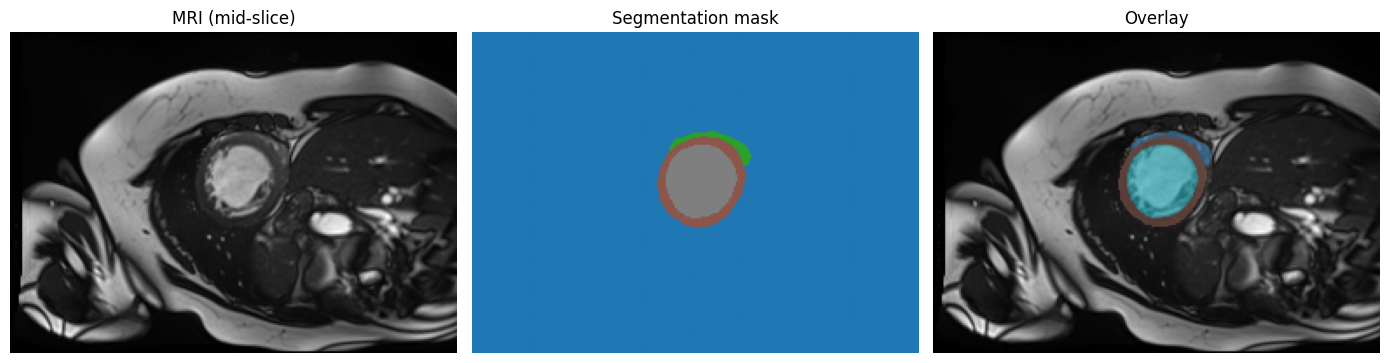

Foreground voxels: 3.71%


In [ ]:
#inspection
import os, random, nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Paths to pre-extracted ACDC files
IMG_DIR = "/content/drive/MyDrive/acdc/data/imagesTr"
LAB_DIR = "/content/drive/MyDrive/acdc/data/labelsTr"

# Pick a random case
sample = random.choice(sorted(os.listdir(IMG_DIR)))
if not sample.endswith(".nii.gz"): sample = "patient001_ED.nii.gz"

img_path = os.path.join(IMG_DIR, sample)
lab_path = os.path.join(LAB_DIR, sample.replace(".nii.gz", "_gt.nii.gz"))

print(f"🔹 Image: {img_path}")
print(f"🔹 Label: {lab_path}")

# Load image and label
img = nib.load(img_path).get_fdata().astype(np.float32)
lab = nib.load(lab_path).get_fdata().astype(np.int32)

print(f"Image shape: {img.shape}, dtype={img.dtype}, min={img.min():.2f}, max={img.max():.2f}")
print(f"Label shape: {lab.shape}, unique labels: {np.unique(lab)}")

# Pick a middle slice for quick check
mid = img.shape[2] // 2

plt.figure(figsize=(14,5))
plt.subplot(1,3,1)
plt.imshow(img[:,:,mid], cmap="gray")
plt.title("MRI (mid-slice)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(lab[:,:,mid], cmap="tab10", vmin=0, vmax=4)
plt.title("Segmentation mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img[:,:,mid], cmap="gray")
plt.imshow(np.ma.masked_where(lab[:,:,mid]==0, lab[:,:,mid]), cmap="tab10", alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

# Compute foreground ratio
fg_ratio = np.mean(lab > 0) * 100
print(f"Foreground voxels: {fg_ratio:.2f}%")


In [3]:
!pip install -q "monai-weekly[nibabel, tqdm]" \
               "torch>=2.3" "torchvision" "torchaudio" \
               "nibabel" "tqdm" "matplotlib" "scikit-image"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 62.6 MB/s eta 0:00:00


In [ ]:
import os, nibabel as nib, numpy as np
import torch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstD, Orientationd, Spacingd,
    ScaleIntensityRanged, CropForegroundd, EnsureTyped, SaveImaged
)
from monai.data import Dataset, DataLoader
from tqdm import tqdm

BASE = "/content/drive/MyDrive/acdc"
IMG_DIR = os.path.join(BASE, "data/imagesTr")
LAB_DIR = os.path.join(BASE, "data/labelsTr")

OUT_IMG = os.path.join(BASE, "preprocessed/images")
OUT_LAB = os.path.join(BASE, "preprocessed/labels")
os.makedirs(OUT_IMG, exist_ok=True)
os.makedirs(OUT_LAB, exist_ok=True)

# Dataset dictionary
files = []
for img_name in sorted(os.listdir(IMG_DIR)):
    if not img_name.endswith(".nii.gz"): continue
    pid = img_name.replace(".nii.gz", "")
    label_name = pid + "_gt.nii.gz"
    img_path = os.path.join(IMG_DIR, img_name)
    lab_path = os.path.join(LAB_DIR, label_name)
    if os.path.exists(lab_path):
        files.append({"image": img_path, "label": lab_path})

print(f"Found {len(files)} image-label pairs for preprocessing.")

# Define preprocessing transforms
pre_tf = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstD(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.25, 1.25, 1.25), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=255, b_min=-1.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    EnsureTyped(keys=["image", "label"]),
    SaveImaged(keys=["image"], output_dir=OUT_IMG, output_postfix="", resample=False, separate_folder=False),
    SaveImaged(keys=["label"], output_dir=OUT_LAB, output_postfix="", resample=False, separate_folder=False),
])

# Data loader
ds = Dataset(data=files, transform=pre_tf)
loader = DataLoader(ds, batch_size=1, num_workers=2)

for _ in tqdm(loader, total=len(loader)):
    pass

print("\n✅ Preprocessing complete.")
print("Saved normalized volumes to:")
print("  📂", OUT_IMG)
print("  📂", OUT_LAB)


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Found 200 image-label pairs for preprocessing.


  0%|          | 0/200 [00:00<?, ?it/s]

2025-10-19 09:17:00,127 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/images/patient001_ED.nii.gz
2025-10-19 09:17:00,147 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/images/patient001_ES.nii.gz
2025-10-19 09:17:01,658 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/labels/patient001_ED_gt.nii.gz
2025-10-19 09:17:01,705 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/labels/patient001_ES_gt.nii.gz


  0%|          | 1/200 [00:04<14:43,  4.44s/it]

...

2025-10-19 09:23:28,077 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/images/patient099_ES.nii.gz
2025-10-19 09:23:29,275 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/images/patient099_ED.nii.gz
2025-10-19 09:23:29,688 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/labels/patient099_ES_gt.nii.gz
2025-10-19 09:23:30,890 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/labels/patient099_ED_gt.nii.gz
2025-10-19 09:23:31,293 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/images/patient100_ES.nii.gz


 98%|█████████▊| 197/200 [06:33<00:04,  1.53s/it]

2025-10-19 09:23:32,571 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/images/patient100_ED.nii.gz
2025-10-19 09:23:32,846 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/labels/patient100_ES_gt.nii.gz
2025-10-19 09:23:33,748 INFO image_writer.py:197 - writing: /content/drive/MyDrive/acdc/preprocessed/labels/patient100_ED_gt.nii.gz


100%|██████████| 200/200 [06:36<00:00,  1.98s/it]


✅ Preprocessing complete.
Saved normalized volumes to:
  📂 /content/drive/MyDrive/acdc/preprocessed/images
  📂 /content/drive/MyDrive/acdc/preprocessed/labels


In [ ]:
# ===========================
# Stage 3 — 3D U-Net training (ACDC)
# Paste into Colab and run (GPU recommended)
# ===========================

import os, glob, json, random, time
from pathlib import Path
from collections import Counter
import numpy as np
import nibabel as nib
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F
from torch.utils.data import DataLoader

from monai.transforms import (
    LoadImaged, EnsureChannelFirstD, Lambdad, Spacingd, Orientationd,
    Compose, RandCropByPosNegLabeld, RandFlipd, RandAffined, ToTensord,
    SpatialPadd, CenterSpatialCropd
)
from monai.data import CacheDataset
from monai.networks.nets import UNet
from monai.losses import DiceLoss

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

BASE = "/content/drive/MyDrive/acdc"   # change if your Drive path differs
PREP_IMG = os.path.join(BASE, "preprocessed/images")
PREP_LAB = os.path.join(BASE, "preprocessed/labels")
CKPT_DIR = os.path.join(BASE, "checkpoints_unet_acdc")
os.makedirs(CKPT_DIR, exist_ok=True)

CLASS_IDS = [1,2,3]        # ACDC labels: usually 1=RV,2=MYO,3=LV (0 is background)
NUM_CLASSES = 1 + len(CLASS_IDS)  # background + 3
LABEL_NAMES = {0:"BG",1:"RV",2:"MYO",3:"LV"}

# Hyperparameters (safe starting point for Colab T4)
PATCH_SIZE = (96, 96, 16)   # (H, W, D) — ACDC stacks are shallow; adjust if needed
BATCH_SIZE = 2
LR = 2e-4
EPOCHS = 120
PATIENCE = 40
N_FOLDS = 4
SEED = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ---------------- Helpers ----------------
def find_cases(img_dir, lab_dir):
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.nii*")))
    labs = sorted(glob.glob(os.path.join(lab_dir, "*.nii*")))
    img_map = {Path(p).stem.split(".")[0]: p for p in imgs}
    lab_map = {Path(p).stem.split(".")[0].replace("_gt",""): p for p in labs}
    ids = sorted(set(img_map.keys()) & set(lab_map.keys()))
    return [{'image': img_map[i], 'label': lab_map[i], 'id': i} for i in ids]

def compute_ce_weights(label_paths):
    counts = Counter()
    for p in label_paths:
        arr = nib.load(p).get_fdata().astype(np.int32)
        unique, c = np.unique(arr, return_counts=True)
        for u,ct in zip(unique, c):
            counts[int(u)] += int(ct)
    freq = np.array([counts.get(i,0)+1 for i in range(NUM_CLASSES)], dtype=np.float64)
    inv = 1.0 / np.sqrt(freq)
    weights = inv / inv.sum() * NUM_CLASSES
    weights = np.clip(weights, 0.05, 20.0)
    return weights, counts

# ---------------- Transforms ----------------
def build_transforms(train=True, patch_size=PATCH_SIZE):
    base = [
        LoadImaged(keys=['image','label']),
        EnsureChannelFirstD(keys=['image','label']),
        Spacingd(keys=['image','label'], pixdim=(1.25,1.25,1.25), mode=('bilinear','nearest')),
        Orientationd(keys=['image','label'], axcodes='RAS'),
        Lambdad(keys=['label'], func=lambda x: np.asarray(x, dtype=np.int32)),
    ]
    if train:
        base += [
            SpatialPadd(keys=['image','label'], spatial_size=patch_size, mode='constant'),
            RandCropByPosNegLabeld(
                keys=['image','label'],
                label_key='label',
                spatial_size=patch_size,
                pos=10, neg=1, num_samples=8
            ),
            RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=0),
            RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=1),
            RandAffined(
                keys=['image','label'],
                prob=0.3,
                rotate_range=(0.1,0.1,0.0),
                scale_range=(0.1,0.1,0.0),
                mode=('bilinear','nearest'),
                padding_mode='zeros'
            ),
        ]
    else:
        base += [
            SpatialPadd(keys=['image','label'], spatial_size=patch_size, mode='constant'),
            CenterSpatialCropd(keys=['image','label'], roi_size=patch_size),
        ]
    base += [ToTensord(keys=['image','label'])]
    return Compose(base)

# ---------------- Model & Loss ----------------
def build_unet():
    return UNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=NUM_CLASSES,
        channels=(16, 32, 64, 128),
        strides=(2,2,2),
        num_res_units=2
    )

class WeightedDiceCELoss(nn.Module):
    def __init__(self, dice_w=1.0, ce_w=0.05, ce_weights=None):
        super().__init__()
        self.dice = DiceLoss(to_onehot_y=True, softmax=True, include_background=False)
        self.dice_w = dice_w
        self.ce_w = ce_w
        self.ce_weights = torch.tensor(ce_weights, dtype=torch.float32) if ce_weights is not None else None
    def forward(self, logits, target):
        target_ce = target.squeeze(1).long() if target.ndim==5 else target.long()
        if self.ce_weights is not None:
            ce = F.cross_entropy(logits, target_ce, weight=self.ce_weights.to(logits.device), label_smoothing=0.05)
        else:
            ce = F.cross_entropy(logits, target_ce, label_smoothing=0.05)
        dice = self.dice(logits, target)
        return self.dice_w * dice + self.ce_w * ce

# ---------------- Train / Validate ----------------
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total = 0.0
    for batch in loader:
        if isinstance(batch, list): batch = batch[0]
        img = batch['image'].to(device).float()
        lab = batch['label'].to(device).long()
        optimizer.zero_grad()
        logits = model(img)
        loss = loss_fn(logits, lab)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / max(1, len(loader))

def validate(model, loader, device):
    model.eval()
    per_class = {cid: [] for cid in CLASS_IDS}
    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, list): batch = batch[0]
            img = batch['image'].to(device).float()
            gt = batch['label'].cpu().numpy().squeeze().astype(np.int32)
            logits = model(img)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred = probs.argmax(0)
            for cid in CLASS_IDS:
                p = (pred==cid).astype(np.uint8)
                g = (gt==cid).astype(np.uint8)
                inter = (p & g).sum()
                denom = p.sum() + g.sum()
                dice = 0.0 if denom==0 else 2.0*inter/denom
                per_class[cid].append(dice)
    class_means = {c: float(np.mean(per_class[c])) for c in CLASS_IDS}
    mean_dice = float(np.mean(list(class_means.values())))
    return mean_dice, class_means

# ---------------- Cross-validation ----------------
cases = find_cases(PREP_IMG, PREP_LAB)
print("Found cases:", len(cases))
if len(cases) < 10:
    raise SystemExit("Not enough cases!")

random.shuffle(cases)
n = len(cases)
fold_size = max(1, n // N_FOLDS)
results = []

for fold in range(N_FOLDS):
    print("\n" + "="*60)
    print(f"FOLD {fold+1}/{N_FOLDS}")
    val_start = fold * fold_size
    val_end = val_start + fold_size if fold < N_FOLDS-1 else n
    val_cases = cases[val_start:val_end]
    train_cases = cases[:val_start] + cases[val_end:]
    print(" Train:", len(train_cases), "Val:", len(val_cases))

    train_tf = build_transforms(train=True, patch_size=PATCH_SIZE)
    val_tf = build_transforms(train=False, patch_size=PATCH_SIZE)

    train_ds = CacheDataset(data=train_cases, transform=train_tf, cache_rate=0.3, num_workers=4)
    val_ds = CacheDataset(data=val_cases, transform=val_tf, cache_rate=1.0, num_workers=2)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

    model = build_unet().to(DEVICE)
    ce_weights, counts = compute_ce_weights([c['label'] for c in train_cases])
    print("CE weights:", np.round(ce_weights,3))
    loss_fn = WeightedDiceCELoss(dice_w=1.0, ce_w=0.05, ce_weights=ce_weights)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2, eta_min=1e-6)

    best_val = -1.0
    patience = PATIENCE
    best_path = os.path.join(CKPT_DIR, f"unet_acdc_fold{fold}_best.pth")

    for epoch in range(1, EPOCHS+1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
        val_mean_dice, per_class = validate(model, val_loader, DEVICE)
        scheduler.step()
        t1 = time.time()

        print(f"[Fold {fold}] Epoch {epoch}/{EPOCHS} | train_loss={train_loss:.4f} | val_dice={val_mean_dice:.4f} | time={t1-t0:.1f}s")
        print(" per-class:", ", ".join([f"{LABEL_NAMES[c]}:{per_class[c]:.3f}" for c in CLASS_IDS]))

        if val_mean_dice > best_val:
            best_val = val_mean_dice
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_dice': best_val,
                'per_class': per_class
            }, best_path)
            print(" Saved best ->", best_path)
            patience = PATIENCE
        else:
            patience -= 1
            if patience <= 0:
                print("Early stopping triggered")
                break

    results.append({'fold': fold, 'best_dice': best_val, 'path': best_path})
    with open(os.path.join(CKPT_DIR, "cv_results.json"), "w") as f:
        json.dump(results, f, indent=2)

print("\nCV finished. Results:", results)


Device: cuda
Found cases: 200

FOLD 1/4
 Train: 150 Val: 50


Loading dataset: 100%|██████████| 50/50 [00:13<00:00,  3.63it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


CE weights: [0.153 1.337 1.25  1.26 ]
[Fold 0] Epoch 1/120 | train_loss=0.8598 | val_dice=0.4456 | time=57.4s
 per-class: RV:0.282, MYO:0.465, LV:0.589
 Saved best -> /content/drive/MyDrive/acdc/checkpoints_unet_acdc/unet_acdc_fold0_best.pth
[Fold 0] Epoch 2/120 | train_loss=0.7094 | val_dice=0.4989 | time=53.7s
 per-class: RV:0.320, MYO:0.546, LV:0.631
 Saved best -> /content/drive/MyDrive/acdc/checkpoints_unet_acdc/unet_acdc_fold0_best.pth
[Fold 0] Epoch 3/120 | train_loss=0.6495 | val_dice=0.5041 | time=54.3s
 per-class: RV:0.297, MYO:0.562, LV:0.653
 Saved best -> /content/drive/MyDrive/acdc/checkpoints_unet_acdc/unet_acdc_fold0_best.pth
[Fold 0] Epoch 4/120 | train_loss=0.6248 | val_dice=0.5340 | time=53.8s
 per-class: RV:0.354, MYO:0.581, LV:0.666
 Saved best -> /content/drive/MyDrive/acdc/checkpoints_unet_acdc/unet_acdc_fold0_best.pth
[Fold 0] Epoch 5/120 | train_loss=0.6206 | val_dice=0.5622 | time=53.1s
 per-class: RV:0.444, MYO:0.584, LV:0.659
 Saved best -> /content/drive/My

In [ ]:
#Resuming Training
import os, torch, json, time
import torch.nn.functional as F
import numpy as np
from monai.networks.nets import UNet
from monai.losses import DiceLoss

# --- paths ---
BASE = "/content/drive/MyDrive/acdc"
CKPT_DIR = os.path.join(BASE, "checkpoints_unet_acdc")
RESUME_PATH = os.path.join(CKPT_DIR, "unet_acdc_fold0_best.pth")  # update fold if needed
PREP_IMG = os.path.join(BASE, "preprocessed/images")
PREP_LAB = os.path.join(BASE, "preprocessed/labels")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("Resuming from:", RESUME_PATH)

# --- model setup (must match training) ---
NUM_CLASSES = 4
CLASS_IDS = [1,2,3]
LABEL_NAMES = {0:"BG",1:"RV",2:"MYO",3:"LV"}

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=NUM_CLASSES,
    channels=(16, 32, 64, 128),
    strides=(2,2,2),
    num_res_units=2
).to(DEVICE)

checkpoint = torch.load(RESUME_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
start_epoch = checkpoint["epoch"] + 1
best_dice = checkpoint["best_dice"]
print(f"✅ Loaded checkpoint (epoch {start_epoch-1}, best_dice={best_dice:.4f})")

# --- define optimizer, loss, scheduler same as before ---
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2, eta_min=1e-6)

dice_loss = DiceLoss(to_onehot_y=True, softmax=True, include_background=False)

# --- Rebuild data loaders ---
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstD, Orientationd, Spacingd,
    RandCropByPosNegLabeld, RandFlipd, RandAffined, ToTensord,
    SpatialPadd, CenterSpatialCropd, Lambdad
)
from monai.data import CacheDataset
from torch.utils.data import DataLoader
import glob, random
from pathlib import Path

PATCH_SIZE = (96, 96, 16)
BATCH_SIZE = 2
N_FOLDS = 4
SEED = 42
random.seed(SEED)

def find_cases(img_dir, lab_dir):
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.nii*")))
    labs = sorted(glob.glob(os.path.join(lab_dir, "*.nii*")))
    img_map = {Path(p).stem.split(".")[0]: p for p in imgs}
    lab_map = {Path(p).stem.split(".")[0].replace("_gt",""): p for p in labs}
    ids = sorted(set(img_map.keys()) & set(lab_map.keys()))
    return [{'image': img_map[i], 'label': lab_map[i], 'id': i} for i in ids]

cases = find_cases(PREP_IMG, PREP_LAB)
n = len(cases)
fold_size = max(1, n // N_FOLDS)
fold = 0  # change if resuming another fold
val_start = fold * fold_size
val_end = val_start + fold_size if fold < N_FOLDS-1 else n
val_cases = cases[val_start:val_end]
train_cases = cases[:val_start] + cases[val_end:]

def build_transforms(train=True):
    base = [
        LoadImaged(keys=['image','label']),
        EnsureChannelFirstD(keys=['image','label']),
        Spacingd(keys=['image','label'], pixdim=(1.25,1.25,1.25), mode=('bilinear','nearest')),
        Orientationd(keys=['image','label'], axcodes='RAS'),
        Lambdad(keys=['label'], func=lambda x: np.asarray(x, dtype=np.int32)),
    ]
    if train:
        base += [
            SpatialPadd(keys=['image','label'], spatial_size=PATCH_SIZE, mode='constant'),
            RandCropByPosNegLabeld(keys=['image','label'], label_key='label', spatial_size=PATCH_SIZE, pos=10, neg=1, num_samples=8),
            RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=0),
            RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=1),
            RandAffined(keys=['image','label'], prob=0.3, rotate_range=(0.1,0.1,0.0), scale_range=(0.1,0.1,0.0),
                        mode=('bilinear','nearest'), padding_mode='zeros')
        ]
    else:
        base += [
            SpatialPadd(keys=['image','label'], spatial_size=PATCH_SIZE, mode='constant'),
            CenterSpatialCropd(keys=['image','label'], roi_size=PATCH_SIZE),
        ]
    base += [ToTensord(keys=['image','label'])]
    return Compose(base)

train_tf = build_transforms(True)
val_tf = build_transforms(False)

train_ds = CacheDataset(data=train_cases, transform=train_tf, cache_rate=0.3, num_workers=2)
val_ds = CacheDataset(data=val_cases, transform=val_tf, cache_rate=1.0, num_workers=2)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

# --- Resume training ---
def validate(model, loader, device):
    model.eval()
    per_class = {cid: [] for cid in CLASS_IDS}
    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, list): batch = batch[0]
            img = batch['image'].to(device).float()
            gt = batch['label'].cpu().numpy().squeeze().astype(np.int32)
            logits = model(img)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred = probs.argmax(0)
            for cid in CLASS_IDS:
                p = (pred==cid).astype(np.uint8)
                g = (gt==cid).astype(np.uint8)
                inter = (p & g).sum()
                denom = p.sum() + g.sum()
                dice = 0.0 if denom==0 else 2.0*inter/denom
                per_class[cid].append(dice)
    class_means = {c: float(np.mean(per_class[c])) for c in CLASS_IDS}
    mean_dice = float(np.mean(list(class_means.values())))
    return mean_dice, class_means

start = start_epoch
EPOCHS = 120  # total epochs desired
print("\n🚀 Resuming training...")
for epoch in range(start, EPOCHS+1):
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        if isinstance(batch, list): batch = batch[0]
        img = batch["image"].to(DEVICE).float()
        lab = batch["label"].to(DEVICE).long()
        optimizer.zero_grad()
        logits = model(img)
        loss = dice_loss(logits, lab)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    val_mean, per_class = validate(model, val_loader, DEVICE)
    print(f"Epoch {epoch:03d} | Loss={epoch_loss/len(train_loader):.4f} | ValDice={val_mean:.4f} | {per_class}")
    if val_mean > best_dice:
        best_dice = val_mean
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_dice': best_dice,
            'per_class': per_class
        }, RESUME_PATH)
        print(f"💾 Updated best (Dice={best_dice:.4f})")


Using device: cuda
Resuming from: /content/drive/MyDrive/acdc/checkpoints_unet_acdc/unet_acdc_fold0_best.pth
✅ Loaded checkpoint (epoch 78, best_dice=0.8271)


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
Loading dataset: 100%|██████████| 50/50 [00:27<00:00,  1.82it/s]


🚀 Resuming training...


Epoch 079 | Loss=0.2868 | ValDice=0.8149 | {1: 0.7239312335006425, 2: 0.812554386485409, 3: 0.9082163428843032}
Epoch 080 | Loss=0.2838 | ValDice=0.7887 | {1: 0.6775261345326798, 2: 0.8043499739928638, 3: 0.8842960009745707}
Epoch 081 | Loss=0.2921 | ValDice=0.8003 | {1: 0.6959165085989073, 2: 0.8076307511742326, 3: 0.8974342770589229}
Epoch 082 | Loss=0.2930 | ValDice=0.8153 | {1: 0.716841939981004, 2: 0.8179469804692135, 3: 0.9111621479980019}
Epoch 083 | Loss=0.2707 | ValDice=0.7886 | {1: 0.6718626374222625, 2: 0.819334225690169, 3: 0.8747186964622099}
Epoch 084 | Loss=0.3091 | ValDice=0.8171 | {1: 0.7399176693749665, 2: 0.7894778639198045, 3: 0.9220006669651462}
Epoch 085 | Loss=0.2585 | ValDice=0.8258 | {1: 0.7362063066967882, 2: 0.8168751368930964, 3: 0.9244058327352301}
Epoch 086 | Loss=0.3028 | ValDice=0.7958 | {1: 0.6901585749342667, 2: 0.8066657504248654, 3: 0.8905177945379014}
Epoch 087 | Loss=0.2735 | ValDice=0.8292 | {1: 0.736431988906688, 2: 0.8273680294106613, 3: 0.92384

In [4]:
!pip install pyvista

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 MB 7.4 MB/s eta 0:00:00


In [ ]:
import os, torch, nibabel as nib, numpy as np
from monai.networks.nets import UNet
from monai.inferers import sliding_window_inference
from skimage.measure import marching_cubes
from scipy.ndimage import label, binary_closing, generate_binary_structure
import pyvista as pv


# Paths
BASE = "/content/drive/MyDrive/acdc"
CKPT = os.path.join(BASE, "checkpoints_unet_acdc/unet_acdc_fold0_best.pth")
IMG_DIR = os.path.join(BASE, "preprocessed/images")
OUT_DIR = os.path.join(BASE, "predictions_vtp_clean")
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4
print("Device:", DEVICE)

# ---------------- Load Model ----------------
model = UNet(spatial_dims=3, in_channels=1, out_channels=NUM_CLASSES,
             channels=(16, 32, 64, 128), strides=(2,2,2), num_res_units=2)
ckpt = torch.load(CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.to(DEVICE)
model.eval()
print(f"Loaded checkpoint epoch {ckpt['epoch']} | best_dice={ckpt['best_dice']:.4f}")

# ---------------- Pick an image ----------------
test_case = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".nii.gz")])[0]
img_path = os.path.join(IMG_DIR, test_case)
print("Running on:", img_path)

img_nib = nib.load(img_path)
img = img_nib.get_fdata().astype(np.float32)
img_tensor = torch.from_numpy(img[None, None]).to(DEVICE)

# ---------------- Inference ----------------
with torch.no_grad():
    pred = sliding_window_inference(
        inputs=img_tensor, roi_size=(96,96,16),
        sw_batch_size=2, predictor=model, overlap=0.5
    )

pred = torch.softmax(pred, dim=1).detach().cpu().numpy()[0]
seg = np.argmax(pred, axis=0).astype(np.uint8)

# ---------------- Save raw segmentation ----------------
nii_path = os.path.join(OUT_DIR, test_case.replace(".nii.gz", "_pred_raw.nii.gz"))
nib.save(nib.Nifti1Image(seg, img_nib.affine), nii_path)
print(f"✅ Saved raw segmentation mask to {nii_path}")

# ---------------- Clean + Export main heart mesh ----------------
label_names = {1: "RV", 2: "MYO", 3: "LV"}
struct = generate_binary_structure(3, 2)

for cls_id, name in label_names.items():
    mask = (seg == cls_id).astype(np.uint8)
    if mask.sum() < 100:
        continue

    # 1️⃣ Keep only largest connected component
    lbl, num = label(mask, struct)
    if num > 0:
        counts = np.bincount(lbl.flat)[1:]  # skip background
        main_lbl = np.argmax(counts) + 1
        mask = (lbl == main_lbl).astype(np.uint8)

    # 2️⃣ Morphological closing (fill small holes)
    mask = binary_closing(mask, structure=struct, iterations=2).astype(np.uint8)

    # 3️⃣ Mesh extraction
    verts, faces, _, _ = marching_cubes(mask, level=0.5)
    faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32)
    mesh = pv.PolyData(verts, faces)

    # 4️⃣ Laplacian smoothing
    mesh_smooth = mesh.smooth(
        n_iter=50,
        relaxation_factor=0.05,
        boundary_smoothing=True
    )

    vtp_path = os.path.join(OUT_DIR, f"{test_case.replace('.nii.gz','')}_{name}_clean_smooth.vtp")
    mesh_smooth.save(vtp_path)
    print(f"💾 Saved clean, smoothed {name} mesh -> {vtp_path}")

print("\n✅ Done! Only main heart meshes were saved (RV, MYO, LV).")
print("👉 You can open them in ParaView or 3D Slicer for a clear central heart view.")


Device: cpu
Loaded checkpoint epoch 107 | best_dice=0.8391
Running on: /content/drive/MyDrive/acdc/preprocessed/images/patient001_ED.nii.gz
✅ Saved raw segmentation mask to /content/drive/MyDrive/acdc/predictions_vtp_clean/patient001_ED_pred_raw.nii.gz
💾 Saved clean, smoothed RV mesh -> /content/drive/MyDrive/acdc/predictions_vtp_clean/patient001_ED_RV_clean_smooth.vtp
💾 Saved clean, smoothed MYO mesh -> /content/drive/MyDrive/acdc/predictions_vtp_clean/patient001_ED_MYO_clean_smooth.vtp
💾 Saved clean, smoothed LV mesh -> /content/drive/MyDrive/acdc/predictions_vtp_clean/patient001_ED_LV_clean_smooth.vtp

✅ Done! Only main heart meshes were saved (RV, MYO, LV).
👉 You can open them in ParaView or 3D Slicer for a clear central heart view.


In [ ]:
#Improving Dice score
# ===========================================================
# 🔁 Fine-tune 3D U-Net on ACDC — Resume + Improve Performance
# ===========================================================
import os, torch, json, time, random, glob
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.data import CacheDataset
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstD, Orientationd, Spacingd,
    RandCropByPosNegLabeld, RandFlipd, RandAffined, Rand3DElasticd,
    ToTensord, SpatialPadd, CenterSpatialCropd, Lambdad
)
from scipy.ndimage import label
from pathlib import Path

# -----------------------------------------------------------
# Paths & Setup
# -----------------------------------------------------------
BASE = "/content/drive/MyDrive/acdc"
CKPT_DIR = os.path.join(BASE, "checkpoints_unet_acdc")
RESUME_PATH = os.path.join(CKPT_DIR, "unet_acdc_fold0_best.pth")
PREP_IMG = os.path.join(BASE, "preprocessed/images")
PREP_LAB = os.path.join(BASE, "preprocessed/labels")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("Resuming from:", RESUME_PATH)

NUM_CLASSES = 4
CLASS_IDS = [1,2,3]
LABEL_NAMES = {0:"BG",1:"RV",2:"MYO",3:"LV"}

# -----------------------------------------------------------
# Model Definition (same as training)
# -----------------------------------------------------------
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=NUM_CLASSES,
    channels=(16, 32, 64, 128),
    strides=(2,2,2),
    num_res_units=2
).to(DEVICE)

checkpoint = torch.load(RESUME_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
start_epoch = checkpoint["epoch"] + 1
best_dice = checkpoint["best_dice"]
print(f"✅ Loaded checkpoint (epoch {start_epoch-1}, best_dice={best_dice:.4f})")

# -----------------------------------------------------------
# Loss — Dice + Focal combo for class imbalance
# -----------------------------------------------------------
class DiceFocalLoss(torch.nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super().__init__()
        self.dice = DiceLoss(to_onehot_y=True, softmax=True, include_background=False)
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, target):
        dice = self.dice(logits, target)
        target = target.squeeze(1).long()
        ce = F.cross_entropy(logits, target, reduction='none')
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma * ce).mean()
        return dice + self.alpha * focal

loss_fn = DiceFocalLoss(alpha=0.5, gamma=2.0)

# -----------------------------------------------------------
# Optimizer & Scheduler — lower LR for fine-tuning
# -----------------------------------------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

# -----------------------------------------------------------
# Dataset & Dataloaders
# -----------------------------------------------------------
PATCH_SIZE = (128, 128, 16)
BATCH_SIZE = 2
N_FOLDS = 4
SEED = 42
random.seed(SEED)

def find_cases(img_dir, lab_dir):
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.nii*")))
    labs = sorted(glob.glob(os.path.join(lab_dir, "*.nii*")))
    img_map = {Path(p).stem.split(".")[0]: p for p in imgs}
    lab_map = {Path(p).stem.split(".")[0].replace("_gt",""): p for p in labs}
    ids = sorted(set(img_map.keys()) & set(lab_map.keys()))
    return [{'image': img_map[i], 'label': lab_map[i], 'id': i} for i in ids]

cases = find_cases(PREP_IMG, PREP_LAB)
n = len(cases)
fold_size = max(1, n // N_FOLDS)
fold = 0  # change if resuming another fold
val_start = fold * fold_size
val_end = val_start + fold_size if fold < N_FOLDS-1 else n
val_cases = cases[val_start:val_end]
train_cases = cases[:val_start] + cases[val_end:]

def build_transforms(train=True):
    base = [
        LoadImaged(keys=['image','label']),
        EnsureChannelFirstD(keys=['image','label']),
        Spacingd(keys=['image','label'], pixdim=(1.25,1.25,1.25), mode=('bilinear','nearest')),
        Orientationd(keys=['image','label'], axcodes='RAS'),
        Lambdad(keys=['label'], func=lambda x: np.asarray(x, dtype=np.int32)),
    ]
    if train:
        base += [
            SpatialPadd(keys=['image','label'], spatial_size=PATCH_SIZE, mode='constant'),
            RandCropByPosNegLabeld(keys=['image','label'], label_key='label',
                                   spatial_size=PATCH_SIZE, pos=10, neg=1, num_samples=8),
            RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=[0,1]),
            RandAffined(keys=['image','label'], prob=0.4,
                        rotate_range=(0.2,0.2,0.1), scale_range=(0.15,0.15,0.05),
                        mode=('bilinear','nearest'), padding_mode='zeros'),
            Rand3DElasticd(keys=['image','label'], prob=0.2, sigma_range=(5,8),
                           magnitude_range=(50,100), mode=("bilinear","nearest"))
        ]
    else:
        base += [
            SpatialPadd(keys=['image','label'], spatial_size=PATCH_SIZE, mode='constant'),
            CenterSpatialCropd(keys=['image','label'], roi_size=PATCH_SIZE),
        ]
    base += [ToTensord(keys=['image','label'])]
    return Compose(base)

train_tf = build_transforms(True)
val_tf = build_transforms(False)

train_ds = CacheDataset(data=train_cases, transform=train_tf, cache_rate=0.3, num_workers=2)
val_ds = CacheDataset(data=val_cases, transform=val_tf, cache_rate=1.0, num_workers=2)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

# -----------------------------------------------------------
# Validation Function with Post-processing
# -----------------------------------------------------------
def clean_mask(seg):
    """Keep only the largest connected component per class."""
    out = np.zeros_like(seg)
    for cls in CLASS_IDS:
        lbl, num = label(seg == cls)
        if num > 0:
            largest = np.argmax(np.bincount(lbl.flat)[1:]) + 1
            out[lbl == largest] = cls
    return out

def validate(model, loader, device):
    model.eval()
    per_class = {cid: [] for cid in CLASS_IDS}
    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, list): batch = batch[0]
            img = batch['image'].to(device).float()
            gt = batch['label'].cpu().numpy().squeeze().astype(np.int32)
            logits = model(img)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred = probs.argmax(0)
            pred = clean_mask(pred)  # post-processing
            for cid in CLASS_IDS:
                p = (pred==cid).astype(np.uint8)
                g = (gt==cid).astype(np.uint8)
                inter = (p & g).sum()
                denom = p.sum() + g.sum()
                dice = 0.0 if denom==0 else 2.0*inter/denom
                per_class[cid].append(dice)
    class_means = {c: float(np.mean(per_class[c])) for c in CLASS_IDS}
    mean_dice = float(np.mean(list(class_means.values())))
    return mean_dice, class_means

# -----------------------------------------------------------
# Fine-tune Loop (e.g., 15–25 more epochs)
# -----------------------------------------------------------
EPOCHS = 140  # continue beyond 120
print("\n🚀 Fine-tuning from epoch", start_epoch)

for epoch in range(start_epoch, EPOCHS+1):
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        if isinstance(batch, list): batch = batch[0]
        img = batch["image"].to(DEVICE).float()
        lab = batch["label"].to(DEVICE).long()
        optimizer.zero_grad()
        logits = model(img)
        loss = loss_fn(logits, lab)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    val_mean, per_class = validate(model, val_loader, DEVICE)
    print(f"Epoch {epoch:03d} | Loss={epoch_loss/len(train_loader):.4f} | ValDice={val_mean:.4f} | {per_class}")
    if val_mean > best_dice:
        best_dice = val_mean
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_dice': best_dice,
            'per_class': per_class
        }, RESUME_PATH)
        print(f"💾 Updated best (Dice={best_dice:.4f})")


Using device: cuda
Resuming from: /content/drive/MyDrive/acdc/checkpoints_unet_acdc/unet_acdc_fold0_best.pth
✅ Loaded checkpoint (epoch 107, best_dice=0.8391)


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
Loading dataset: 100%|██████████| 50/50 [00:28<00:00,  1.78it/s]


🚀 Fine-tuning from epoch 108


Epoch 108 | Loss=0.4403 | ValDice=0.8554 | {1: 0.80072610687292, 2: 0.8339977832468766, 3: 0.9313702869311007}
💾 Updated best (Dice=0.8554)
Epoch 109 | Loss=0.3571 | ValDice=0.8551 | {1: 0.7985154601541378, 2: 0.8346931315727976, 3: 0.9322145271714226}
Epoch 110 | Loss=0.3265 | ValDice=0.8603 | {1: 0.8031287150516461, 2: 0.8395383086238983, 3: 0.9381041843319988}
💾 Updated best (Dice=0.8603)
Epoch 111 | Loss=0.3329 | ValDice=0.8563 | {1: 0.8121743453423441, 2: 0.8248809813819261, 3: 0.9319069599820581}
Epoch 112 | Loss=0.2900 | ValDice=0.8607 | {1: 0.8121708615324552, 2: 0.8366177787455048, 3: 0.9334056766725114}
💾 Updated best (Dice=0.8607)
Epoch 113 | Loss=0.3017 | ValDice=0.8596 | {1: 0.8115877208463675, 2: 0.8324423350893272, 3: 0.9348656475726759}
Epoch 114 | Loss=0.3153 | ValDice=0.8590 | {1: 0.8108395184890198, 2: 0.8332050639541593, 3: 0.9328528637109362}
Epoch 115 | Loss=0.2638 | ValDice=0.8597 | {1: 0.8100934785580638, 2: 0.8339527000396002, 3: 0.9352023577846776}
Epoch 116 |

In [ ]:
import torch
print(torch.__version__, torch.version.cuda)


2.8.0+cu126 12.6


In [ ]:
# ============================================================
# 🚀  Fast install for PyTorch 2.8.0 + CUDA 12.6 (Colab 2025)
# ============================================================
# Uninstall conflicting old packages if any
!pip uninstall -y torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric pyg_lib 2>/dev/null

# ✅ Install precompiled CUDA 12.6-compatible wheels
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv torch_geometric \
    -f https://data.pyg.org/whl/torch-2.8.0+cu126.html --quiet

# Supporting packages (for mesh + medical)
!pip install pyvista monai nibabel scikit-image --quiet

import torch
print("✅ PyTorch:", torch.__version__, "| CUDA:", torch.version.cuda)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 71.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 115.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 127.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 128.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 76.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 MB 7.3 MB/s eta 0:00:00
✅ PyTorch: 2.8.0+cu126 | CUDA: 12.6


In [ ]:
# ============================
# GCN Refinement — Memory-safe fixed cell
# ============================
import os, torch, numpy as np, nibabel as nib, pyvista as pv, random
from skimage.measure import marching_cubes
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch.utils.data import Dataset
from monai.networks.nets import UNet
from monai.inferers import sliding_window_inference
import gc

# ---------------- CONFIG ----------------
BASE = "/content/drive/MyDrive/acdc"
CKPT_UNET = os.path.join(BASE, "checkpoints_unet_acdc/unet_acdc_fold0_best.pth")
IMG_DIR = os.path.join(BASE, "preprocessed/images")
LAB_DIR = os.path.join(BASE, "preprocessed/labels")
OUT_BASE = os.path.join(BASE, "gcn_refinement")
os.makedirs(OUT_BASE, exist_ok=True)
os.makedirs(os.path.join(OUT_BASE, "checkpoints"), exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------- load U-Net ----------------
NUM_CLASSES = 4
LABEL_NAMES = {1:"RV", 2:"MYO", 3:"LV"}

unet = UNet(spatial_dims=3, in_channels=1, out_channels=NUM_CLASSES,
            channels=(16,32,64,128), strides=(2,2,2), num_res_units=2)
ckpt = torch.load(CKPT_UNET, map_location=DEVICE)
unet.load_state_dict(ckpt["model_state_dict"])
unet.to(DEVICE).eval()
print(f"Loaded U-Net epoch {ckpt['epoch']} best_dice={ckpt['best_dice']:.4f}")

# ---------------- helpers (fixed) ----------------
def mesh_to_graph(verts, faces):
    # ensure contiguous (+ copy) to avoid stride issues
    verts = np.ascontiguousarray(verts.copy())
    faces = np.ascontiguousarray(faces.copy())
    if faces.ndim == 2 and faces.shape[1] >= 3:
        # Triangles assumed, take first 3 columns
        faces_tri = faces[:, :3].astype(np.int64)
    else:
        faces_tri = faces.astype(np.int64)
    # build unique undirected edges (triangle edges)
    edges = np.vstack([
        np.stack([faces_tri[:,0], faces_tri[:,1]], 1),
        np.stack([faces_tri[:,1], faces_tri[:,2]], 1),
        np.stack([faces_tri[:,2], faces_tri[:,0]], 1)
    ])
    edges = np.unique(np.sort(edges, axis=1), axis=0)
    edge_index = torch.tensor(edges.T, dtype=torch.long)
    x = torch.tensor(verts, dtype=torch.float)
    return Data(x=x, edge_index=edge_index)

def safe_marching(mask):
    # ensure mask is contiguous boolean array
    mask = np.ascontiguousarray(mask.astype(np.uint8))
    # if empty mask -> raise
    if mask.sum() < 10:
        raise ValueError("Mask too small for marching_cubes")
    verts, faces, _, _ = marching_cubes(mask, level=0.5)
    return verts, faces

# ---------------- memory-safe Chamfer (sample + chunk) ----------------
def sample_chamfer_loss(pred, gt, k=1024, chunk=512):
    """
    pred: (N_pred,3) tensor
    gt:   (N_gt,3) tensor
    approximate Chamfer by random sampling up to k points from each set,
    compute pairwise squared distances in memory-chunked manner if needed.
    """
    # convert to float and device handled by caller
    if pred.shape[0] == 0 or gt.shape[0] == 0:
        return torch.tensor(0.0, device=pred.device)

    n1 = pred.shape[0]
    n2 = gt.shape[0]
    # sample indices
    if n1 > k:
        idx1 = torch.randperm(n1, device=pred.device)[:k]
        p = pred[idx1]
    else:
        p = pred
    if n2 > k:
        idx2 = torch.randperm(n2, device=gt.device)[:k]
        g = gt[idx2]
    else:
        g = gt

    # now compute dists in chunks to avoid OOM
    # p: P x 3, g: G x 3
    P = p.shape[0]; G = g.shape[0]

    # p->g: for each p, min distance to any g
    mins_p = []
    i = 0
    while i < P:
        j = min(P, i + chunk)
        # compute squared euclidean between p[i:j] and g: (j-i) x G
        d = torch.cdist(p[i:j], g, p=2)  # uses moderate memory
        mins_p.append(d.min(dim=1)[0])
        i = j
    mins_p = torch.cat(mins_p)  # length P

    # g->p: for each g, min distance to any p
    mins_g = []
    i = 0
    while i < G:
        j = min(G, i + chunk)
        d = torch.cdist(g[i:j], p, p=2)
        mins_g.append(d.min(dim=1)[0])
        i = j
    mins_g = torch.cat(mins_g)

    return mins_p.mean() + mins_g.mean()

def laplacian_loss(verts, edge_index):
    # edge_index: (2, E)
    v1 = edge_index[0].long()
    v2 = edge_index[1].long()
    return ((verts[v1] - verts[v2])**2).sum(dim=1).mean()

# ---------------- Dataset ----------------
class MeshPairDataset(Dataset):
    def __init__(self, img_dir, lab_dir, label_id=3, limit=10):
        self.imgs = sorted([f for f in os.listdir(img_dir) if f.endswith(".nii.gz")])[:limit]
        self.img_dir = img_dir
        self.lab_dir = lab_dir
        self.label_id = label_id

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # choose idx safely
        idx = idx % len(self.imgs)
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        lab_path = os.path.join(self.lab_dir, img_name.replace(".nii.gz", "_gt.nii.gz"))

        img_nib = nib.load(img_path)
        img = img_nib.get_fdata().astype(np.float32)
        img_t = torch.from_numpy(img[None, None]).to(DEVICE)

        with torch.no_grad():
            pred_logits = sliding_window_inference(img_t, (96,96,16), sw_batch_size=1, predictor=unet, overlap=0.5)
        pred = torch.softmax(pred_logits, dim=1).cpu().numpy()[0].argmax(0)

        gt = nib.load(lab_path).get_fdata().astype(np.int32)

        pred_mask = (pred == self.label_id).astype(np.uint8)
        gt_mask = (gt == self.label_id).astype(np.uint8)

        # try safe marching cubes
        try:
            verts_p, faces_p = safe_marching(pred_mask)
            verts_g, faces_g = safe_marching(gt_mask)
        except Exception as e:
            # if problem, try a neighboring index
            # print("Skipping invalid mesh:", e)
            return self.__getitem__((idx + 1) % len(self.imgs))

        g_data = mesh_to_graph(verts_p, faces_p)  # PyG Data for pred
        gt_verts = np.ascontiguousarray(verts_g.copy())
        gt_verts = torch.tensor(gt_verts, dtype=torch.float)  # CPU tensor (moved to device later)

        return g_data, gt_verts

# ---------------- small GCN ----------------
class MeshRefineNet(torch.nn.Module):
    def __init__(self, in_feats=3, hidden=32):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, 3)
    def forward(self, x, edge_index):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        return self.conv3(x, edge_index)

# ---------------- training loop (memory-safe) ----------------
from torch_geometric.loader import DataLoader as GeomLoader

label_id = 3    # 1=RV,2=MYO,3=LV
limit = 10      # number of patients to use for GCN training (start small)
ds = MeshPairDataset(IMG_DIR, LAB_DIR, label_id=label_id, limit=limit)
dl = GeomLoader(ds, batch_size=1, shuffle=True, num_workers=0)

model = MeshRefineNet(hidden=32).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30
sample_k = 1024   # number of points to sample for chamfer (lower -> less memory, faster)
chunk = 512       # chunk size for cdist (lower -> less memory)

best_loss = float("inf")
print(f"Training GCN on {len(ds)} pairs (label {LABEL_NAMES[label_id]}) on {DEVICE}")
for epoch in range(1, EPOCHS+1):
    model.train()
    total = 0.0
    torch.cuda.empty_cache(); gc.collect()
    for batch in dl:
        # batch is (Data, gt_verts) because our Dataset returns tuple
        data, gt_verts = batch  # data is PyG Data (batched), gt_verts is list of tensors
        # If PyG returns a list-like, unpack
        if isinstance(data, list) and len(data) == 2:
            data, gt_verts = data
        # Move PyG Data to device
        data = data.to(DEVICE)
        # gt_verts may come as list/tuple depending on loader; coerce to tensor
        if isinstance(gt_verts, (list, tuple)):
            gt_verts = gt_verts[0]
        gt_verts = gt_verts.to(DEVICE)

        opt.zero_grad()
        delta = model(data.x, data.edge_index)   # (N,3)
        pred_verts = data.x + delta              # (N,3)

        try:
            loss_ch = sample_chamfer_loss(pred_verts, gt_verts, k=sample_k, chunk=chunk)
        except RuntimeError as e:
            # OOM fallback: reduce sample_k and chunk, clear cache and retry
            torch.cuda.empty_cache(); gc.collect()
            sample_k = max(256, sample_k // 2)
            chunk = max(128, chunk // 2)
            loss_ch = sample_chamfer_loss(pred_verts, gt_verts, k=sample_k, chunk=chunk)

        loss_lap = laplacian_loss(pred_verts, data.edge_index.to(DEVICE))
        loss = loss_ch + 0.1 * loss_lap
        loss.backward()
        opt.step()
        total += float(loss.item())

    avg = total / len(dl) if len(dl) > 0 else total
    if avg < best_loss:
        best_loss = avg
        torch.save(model.state_dict(), os.path.join(OUT_BASE, "checkpoints", f"gcn_best_label{label_id}.pth"))
    print(f"Epoch {epoch:03d} | Loss={avg:.6f} (best={best_loss:.6f})")

print("Training finished. best_loss:", best_loss)

# ---------------- apply to one sample and export VTP ----------------
# pick the first valid sample
for i in range(len(ds)):
    try:
        data, gt = ds[i]
        break
    except:
        continue

data = data.to(DEVICE)
model.eval()
with torch.no_grad():
    refined = data.x + model(data.x, data.edge_index)
verts = refined.cpu().numpy()

# Simple triangulation heuristic for faces (if faces info lost we try to keep original)
# Best: reuse original faces from ds; for simplicity, we triangulate using Delaunay in pyvista if needed.
try:
    # Try to load faces via a fresh marching from predicted mask if available in ds (not directly), fallback:
    # Create polydata via PyVista from verts only - PyVista can create a surface via Delaunay3D or ConvexHull
    cloud = pv.PolyData(verts)
    surf = cloud.delaunay_3d(alpha=1.0).extract_geometry()
    out_path = os.path.join(OUT_BASE, f"{LABEL_NAMES[label_id]}_refined.vtp")
    surf.save(out_path)
    print("Saved refined mesh:", out_path)
except Exception as e:
    print("Warning: unable to triangulate with pyvista; saving point cloud as .ply instead.")
    pts_path = os.path.join(OUT_BASE, f"{LABEL_NAMES[label_id]}_refined_points.ply")
    pv.PolyData(verts).save(pts_path)
    print("Saved points:", pts_path)

# free memory
del model, unet, dl, ds
torch.cuda.empty_cache(); gc.collect()


Device: cuda
Loaded U-Net epoch 118 best_dice=0.8623
Training GCN on 10 pairs (label LV) on cuda


/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  win_data = inputs[unravel_slice[0]].to(sw_device)


Epoch 001 | Loss=64.975797 (best=64.975797)
Epoch 002 | Loss=46.281258 (best=46.281258)
Epoch 003 | Loss=43.607883 (best=43.607883)
Epoch 004 | Loss=40.358367 (best=40.358367)
Epoch 005 | Loss=38.270584 (best=38.270584)
Epoch 006 | Loss=38.157775 (best=38.157775)
Epoch 007 | Loss=37.020359 (best=37.020359)
Epoch 008 | Loss=36.585364 (best=36.585364)
Epoch 009 | Loss=36.821019 (best=36.585364)
Epoch 010 | Loss=34.943608 (best=34.943608)
Epoch 011 | Loss=36.306905 (best=34.943608)
Epoch 012 | Loss=34.851608 (best=34.851608)
Epoch 013 | Loss=35.052560 (best=34.851608)
Epoch 014 | Loss=34.196245 (best=34.196245)
Epoch 015 | Loss=34.048424 (best=34.048424)
Epoch 016 | Loss=33.904202 (best=33.904202)
Epoch 017 | Loss=33.666260 (best=33.666260)
Epoch 018 | Loss=33.224213 (best=33.224213)
Epoch 019 | Loss=33.063473 (best=33.063473)
Epoch 020 | Loss=32.856222 (best=32.856222)
Epoch 021 | Loss=33.531055 (best=32.856222)
Epoch 022 | Loss=33.289100 (best=32.856222)
Epoch 023 | Loss=33.812954 (best

4

In [ ]:
import math
best_loss_vox = 32.5652
spacing_mm = 1.25
chamfer_mm = math.sqrt(best_loss_vox) * spacing_mm
print(f"Chamfer ≈ {chamfer_mm:.2f} mm")


Chamfer ≈ 7.13 mm


In [ ]:
# ============================================================
# 🧠 GCN Refinement — Clean VTP Output (Fixed for SciPy Label)
# ============================================================
import os, torch, numpy as np, nibabel as nib, pyvista as pv
from skimage.measure import marching_cubes
from scipy.ndimage import label   # ✅ correct import here!
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from monai.networks.nets import UNet
from monai.inferers import sliding_window_inference

# ---------------- CONFIG ----------------
BASE = "/content/drive/MyDrive/acdc"
CKPT_UNET = os.path.join(BASE, "checkpoints_unet_acdc/unet_acdc_fold0_best.pth")
CKPT_GCN = os.path.join(BASE, "gcn_refinement/checkpoints/gcn_best_label3.pth")  # LV GCN
IMG_PATH = os.path.join(BASE, "preprocessed/images/patient001_ED.nii.gz")
OUT_PATH_RAW = os.path.join(BASE, "gcn_refinement/patient001_ED_LV_raw.vtp")
OUT_PATH_REFINED = os.path.join(BASE, "gcn_refinement/patient001_ED_LV_refined.vtp")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4
LABEL_NAMES = {1:"RV",2:"MYO",3:"LV"}
label_id = 3   # LV
print("Device:", DEVICE)

# ---------------- Load U-Net ----------------
unet = UNet(spatial_dims=3, in_channels=1, out_channels=NUM_CLASSES,
            channels=(16,32,64,128), strides=(2,2,2), num_res_units=2)
ckpt_u = torch.load(CKPT_UNET, map_location=DEVICE)
unet.load_state_dict(ckpt_u["model_state_dict"])
unet.to(DEVICE).eval()
print(f"✅ Loaded U-Net | Epoch {ckpt_u['epoch']} | Dice={ckpt_u['best_dice']:.4f}")

# ---------------- Load trained GCN ----------------
class MeshRefineNet(torch.nn.Module):
    def __init__(self, in_feats=3, hidden=32):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, 3)
    def forward(self, x, edge_index):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        return self.conv3(x, edge_index)

gcn = MeshRefineNet(hidden=32).to(DEVICE)
gcn.load_state_dict(torch.load(CKPT_GCN, map_location=DEVICE))
gcn.eval()
print(f"✅ Loaded trained GCN from: {CKPT_GCN}")

# ---------------- Helper ----------------
def keep_largest_component(mask):
    """Keep only the largest connected component in the mask."""
    lbl, num = label(mask)  # ✅ now correct: returns (labeled_array, num_features)
    if num > 0:
        counts = np.bincount(lbl.flat)[1:]
        largest = 1 + np.argmax(counts)
        mask = (lbl == largest).astype(np.uint8)
    return mask

def mesh_to_graph(verts, faces):
    edges = np.vstack([
        np.stack([faces[:,0], faces[:,1]], 1),
        np.stack([faces[:,1], faces[:,2]], 1),
        np.stack([faces[:,2], faces[:,0]], 1)
    ])
    edges = np.unique(np.sort(edges, axis=1), axis=0)
    edge_index = torch.tensor(edges.T, dtype=torch.long)
    x = torch.tensor(np.ascontiguousarray(verts), dtype=torch.float)
    return Data(x=x, edge_index=edge_index)

# ---------------- 1️⃣ Run U-Net inference ----------------
img_nib = nib.load(IMG_PATH)
img = img_nib.get_fdata().astype(np.float32)
img_t = torch.from_numpy(img[None,None]).to(DEVICE)

with torch.no_grad():
    pred = sliding_window_inference(img_t, (96,96,16), 2, unet, overlap=0.5)
pred = torch.softmax(pred, dim=1).cpu().numpy()[0].argmax(0)

# clean mask: only largest component
mask = (pred == label_id).astype(np.uint8)
mask = keep_largest_component(mask)

# ---------------- 2️⃣ Convert to raw mesh ----------------
verts, faces, _, _ = marching_cubes(mask, level=0.5)
faces_vtp = np.hstack([np.full((faces.shape[0],1),3), faces]).astype(np.int32)

# save raw U-Net mesh
pv.PolyData(verts, faces_vtp).save(OUT_PATH_RAW)
print(f"💾 Saved raw U-Net mesh -> {OUT_PATH_RAW}")

# ---------------- 3️⃣ Convert to graph & refine with GCN ----------------
graph = mesh_to_graph(verts, faces).to(DEVICE)
with torch.no_grad():
    refined = graph.x + gcn(graph.x, graph.edge_index)

verts_ref = refined.cpu().numpy()
faces_ref = np.hstack([np.full((faces.shape[0],1),3), faces]).astype(np.int32)

mesh_refined = pv.PolyData(verts_ref, faces_ref)
mesh_refined.save(OUT_PATH_REFINED)
print(f"💾 Saved refined (GCN-smoothed) mesh -> {OUT_PATH_REFINED}")

print("\n✅ All done! Clean, refined meshes saved in your Drive.")


Device: cuda
✅ Loaded U-Net | Epoch 118 | Dice=0.8623
✅ Loaded trained GCN from: /content/drive/MyDrive/acdc/gcn_refinement/checkpoints/gcn_best_label3.pth
💾 Saved raw U-Net mesh -> /content/drive/MyDrive/acdc/gcn_refinement/patient001_ED_LV_raw.vtp
💾 Saved refined (GCN-smoothed) mesh -> /content/drive/MyDrive/acdc/gcn_refinement/patient001_ED_LV_refined.vtp

✅ All done! Clean, refined meshes saved in your Drive.


In [ ]:
#Training for RV
# ============================
# GCN Refinement — Memory-safe fixed cell
# ============================
import os, torch, numpy as np, nibabel as nib, pyvista as pv, random
from skimage.measure import marching_cubes
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch.utils.data import Dataset
from monai.networks.nets import UNet
from monai.inferers import sliding_window_inference
import gc

# ---------------- CONFIG ----------------
BASE = "/content/drive/MyDrive/acdc"
CKPT_UNET = os.path.join(BASE, "checkpoints_unet_acdc/unet_acdc_fold0_best.pth")
IMG_DIR = os.path.join(BASE, "preprocessed/images")
LAB_DIR = os.path.join(BASE, "preprocessed/labels")
OUT_BASE = os.path.join(BASE, "gcn_refinement")
os.makedirs(OUT_BASE, exist_ok=True)
os.makedirs(os.path.join(OUT_BASE, "checkpoints"), exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------- load U-Net ----------------
NUM_CLASSES = 4
LABEL_NAMES = {1:"RV", 2:"MYO", 3:"LV"}

unet = UNet(spatial_dims=3, in_channels=1, out_channels=NUM_CLASSES,
            channels=(16,32,64,128), strides=(2,2,2), num_res_units=2)
ckpt = torch.load(CKPT_UNET, map_location=DEVICE)
unet.load_state_dict(ckpt["model_state_dict"])
unet.to(DEVICE).eval()
print(f"Loaded U-Net epoch {ckpt['epoch']} best_dice={ckpt['best_dice']:.4f}")

# ---------------- helpers (fixed) ----------------
def mesh_to_graph(verts, faces):
    # ensure contiguous (+ copy) to avoid stride issues
    verts = np.ascontiguousarray(verts.copy())
    faces = np.ascontiguousarray(faces.copy())
    if faces.ndim == 2 and faces.shape[1] >= 3:
        # Triangles assumed, take first 3 columns
        faces_tri = faces[:, :3].astype(np.int64)
    else:
        faces_tri = faces.astype(np.int64)
    # build unique undirected edges (triangle edges)
    edges = np.vstack([
        np.stack([faces_tri[:,0], faces_tri[:,1]], 1),
        np.stack([faces_tri[:,1], faces_tri[:,2]], 1),
        np.stack([faces_tri[:,2], faces_tri[:,0]], 1)
    ])
    edges = np.unique(np.sort(edges, axis=1), axis=0)
    edge_index = torch.tensor(edges.T, dtype=torch.long)
    x = torch.tensor(verts, dtype=torch.float)
    return Data(x=x, edge_index=edge_index)

def safe_marching(mask):
    # ensure mask is contiguous boolean array
    mask = np.ascontiguousarray(mask.astype(np.uint8))
    # if empty mask -> raise
    if mask.sum() < 10:
        raise ValueError("Mask too small for marching_cubes")
    verts, faces, _, _ = marching_cubes(mask, level=0.5)
    return verts, faces

# ---------------- memory-safe Chamfer (sample + chunk) ----------------
def sample_chamfer_loss(pred, gt, k=1024, chunk=512):
    """
    pred: (N_pred,3) tensor
    gt:   (N_gt,3) tensor
    approximate Chamfer by random sampling up to k points from each set,
    compute pairwise squared distances in memory-chunked manner if needed.
    """
    # convert to float and device handled by caller
    if pred.shape[0] == 0 or gt.shape[0] == 0:
        return torch.tensor(0.0, device=pred.device)

    n1 = pred.shape[0]
    n2 = gt.shape[0]
    # sample indices
    if n1 > k:
        idx1 = torch.randperm(n1, device=pred.device)[:k]
        p = pred[idx1]
    else:
        p = pred
    if n2 > k:
        idx2 = torch.randperm(n2, device=gt.device)[:k]
        g = gt[idx2]
    else:
        g = gt

    # now compute dists in chunks to avoid OOM
    # p: P x 3, g: G x 3
    P = p.shape[0]; G = g.shape[0]

    # p->g: for each p, min distance to any g
    mins_p = []
    i = 0
    while i < P:
        j = min(P, i + chunk)
        # compute squared euclidean between p[i:j] and g: (j-i) x G
        d = torch.cdist(p[i:j], g, p=2)  # uses moderate memory
        mins_p.append(d.min(dim=1)[0])
        i = j
    mins_p = torch.cat(mins_p)  # length P

    # g->p: for each g, min distance to any p
    mins_g = []
    i = 0
    while i < G:
        j = min(G, i + chunk)
        d = torch.cdist(g[i:j], p, p=2)
        mins_g.append(d.min(dim=1)[0])
        i = j
    mins_g = torch.cat(mins_g)

    return mins_p.mean() + mins_g.mean()

def laplacian_loss(verts, edge_index):
    # edge_index: (2, E)
    v1 = edge_index[0].long()
    v2 = edge_index[1].long()
    return ((verts[v1] - verts[v2])**2).sum(dim=1).mean()

# ---------------- Dataset ----------------
class MeshPairDataset(Dataset):
    def __init__(self, img_dir, lab_dir, label_id=3, limit=10):
        self.imgs = sorted([f for f in os.listdir(img_dir) if f.endswith(".nii.gz")])[:limit]
        self.img_dir = img_dir
        self.lab_dir = lab_dir
        self.label_id = label_id

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # choose idx safely
        idx = idx % len(self.imgs)
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        lab_path = os.path.join(self.lab_dir, img_name.replace(".nii.gz", "_gt.nii.gz"))

        img_nib = nib.load(img_path)
        img = img_nib.get_fdata().astype(np.float32)
        img_t = torch.from_numpy(img[None, None]).to(DEVICE)

        with torch.no_grad():
            pred_logits = sliding_window_inference(img_t, (96,96,16), sw_batch_size=1, predictor=unet, overlap=0.5)
        pred = torch.softmax(pred_logits, dim=1).cpu().numpy()[0].argmax(0)

        gt = nib.load(lab_path).get_fdata().astype(np.int32)

        pred_mask = (pred == self.label_id).astype(np.uint8)
        gt_mask = (gt == self.label_id).astype(np.uint8)

        # try safe marching cubes
        try:
            verts_p, faces_p = safe_marching(pred_mask)
            verts_g, faces_g = safe_marching(gt_mask)
        except Exception as e:
            # if problem, try a neighboring index
            # print("Skipping invalid mesh:", e)
            return self.__getitem__((idx + 1) % len(self.imgs))

        g_data = mesh_to_graph(verts_p, faces_p)  # PyG Data for pred
        gt_verts = np.ascontiguousarray(verts_g.copy())
        gt_verts = torch.tensor(gt_verts, dtype=torch.float)  # CPU tensor (moved to device later)

        return g_data, gt_verts

# ---------------- small GCN ----------------
class MeshRefineNet(torch.nn.Module):
    def __init__(self, in_feats=3, hidden=32):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, 3)
    def forward(self, x, edge_index):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        return self.conv3(x, edge_index)

# ---------------- training loop (memory-safe) ----------------
from torch_geometric.loader import DataLoader as GeomLoader

label_id = 1    # 1=RV,2=MYO,3=LV
limit = 10      # number of patients to use for GCN training (start small)
ds = MeshPairDataset(IMG_DIR, LAB_DIR, label_id=label_id, limit=limit)
dl = GeomLoader(ds, batch_size=1, shuffle=True, num_workers=0)

model = MeshRefineNet(hidden=32).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30
sample_k = 1024   # number of points to sample for chamfer (lower -> less memory, faster)
chunk = 512       # chunk size for cdist (lower -> less memory)

best_loss = float("inf")
print(f"Training GCN on {len(ds)} pairs (label {LABEL_NAMES[label_id]}) on {DEVICE}")
for epoch in range(1, EPOCHS+1):
    model.train()
    total = 0.0
    torch.cuda.empty_cache(); gc.collect()
    for batch in dl:
        # batch is (Data, gt_verts) because our Dataset returns tuple
        data, gt_verts = batch  # data is PyG Data (batched), gt_verts is list of tensors
        # If PyG returns a list-like, unpack
        if isinstance(data, list) and len(data) == 2:
            data, gt_verts = data
        # Move PyG Data to device
        data = data.to(DEVICE)
        # gt_verts may come as list/tuple depending on loader; coerce to tensor
        if isinstance(gt_verts, (list, tuple)):
            gt_verts = gt_verts[0]
        gt_verts = gt_verts.to(DEVICE)

        opt.zero_grad()
        delta = model(data.x, data.edge_index)   # (N,3)
        pred_verts = data.x + delta              # (N,3)

        try:
            loss_ch = sample_chamfer_loss(pred_verts, gt_verts, k=sample_k, chunk=chunk)
        except RuntimeError as e:
            # OOM fallback: reduce sample_k and chunk, clear cache and retry
            torch.cuda.empty_cache(); gc.collect()
            sample_k = max(256, sample_k // 2)
            chunk = max(128, chunk // 2)
            loss_ch = sample_chamfer_loss(pred_verts, gt_verts, k=sample_k, chunk=chunk)

        loss_lap = laplacian_loss(pred_verts, data.edge_index.to(DEVICE))
        loss = loss_ch + 0.1 * loss_lap
        loss.backward()
        opt.step()
        total += float(loss.item())

    avg = total / len(dl) if len(dl) > 0 else total
    if avg < best_loss:
        best_loss = avg
        torch.save(model.state_dict(), os.path.join(OUT_BASE, "checkpoints", f"gcn_best_label{label_id}.pth"))
    print(f"Epoch {epoch:03d} | Loss={avg:.6f} (best={best_loss:.6f})")

print("Training finished. best_loss:", best_loss)

# ---------------- apply to one sample and export VTP ----------------
# pick the first valid sample
for i in range(len(ds)):
    try:
        data, gt = ds[i]
        break
    except:
        continue

data = data.to(DEVICE)
model.eval()
with torch.no_grad():
    refined = data.x + model(data.x, data.edge_index)
verts = refined.cpu().numpy()

# Simple triangulation heuristic for faces (if faces info lost we try to keep original)
# Best: reuse original faces from ds; for simplicity, we triangulate using Delaunay in pyvista if needed.
try:
    # Try to load faces via a fresh marching from predicted mask if available in ds (not directly), fallback:
    # Create polydata via PyVista from verts only - PyVista can create a surface via Delaunay3D or ConvexHull
    cloud = pv.PolyData(verts)
    surf = cloud.delaunay_3d(alpha=1.0).extract_geometry()
    out_path = os.path.join(OUT_BASE, f"{LABEL_NAMES[label_id]}_refined.vtp")
    surf.save(out_path)
    print("Saved refined mesh:", out_path)
except Exception as e:
    print("Warning: unable to triangulate with pyvista; saving point cloud as .ply instead.")
    pts_path = os.path.join(OUT_BASE, f"{LABEL_NAMES[label_id]}_refined_points.ply")
    pv.PolyData(verts).save(pts_path)
    print("Saved points:", pts_path)

# free memory
del model, unet, dl, ds
torch.cuda.empty_cache(); gc.collect()


Device: cuda
Loaded U-Net epoch 118 best_dice=0.8623
Training GCN on 10 pairs (label RV) on cuda


/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  win_data = inputs[unravel_slice[0]].to(sw_device)


Epoch 001 | Loss=177.880202 (best=177.880202)
Epoch 002 | Loss=121.117348 (best=121.117348)
Epoch 003 | Loss=98.475937 (best=98.475937)
Epoch 004 | Loss=89.728889 (best=89.728889)
Epoch 005 | Loss=84.983510 (best=84.983510)
Epoch 006 | Loss=83.845117 (best=83.845117)
Epoch 007 | Loss=82.609733 (best=82.609733)
Epoch 008 | Loss=81.207356 (best=81.207356)
Epoch 009 | Loss=80.570431 (best=80.570431)
Epoch 010 | Loss=80.217464 (best=80.217464)
Epoch 011 | Loss=78.987038 (best=78.987038)
Epoch 012 | Loss=78.477670 (best=78.477670)
Epoch 013 | Loss=77.556471 (best=77.556471)
Epoch 014 | Loss=76.836675 (best=76.836675)
Epoch 015 | Loss=77.257310 (best=76.836675)
Epoch 016 | Loss=76.189176 (best=76.189176)
Epoch 017 | Loss=75.452475 (best=75.452475)
Epoch 018 | Loss=76.040754 (best=75.452475)
Epoch 019 | Loss=75.540646 (best=75.452475)
Epoch 020 | Loss=75.157026 (best=75.157026)
Epoch 021 | Loss=75.195939 (best=75.157026)
Epoch 022 | Loss=74.968391 (best=74.968391)
Epoch 023 | Loss=74.238409 (

4

In [ ]:
#Training GCN for MYO
# ============================
# GCN Refinement — Memory-safe fixed cell
# ============================
import os, torch, numpy as np, nibabel as nib, pyvista as pv, random
from skimage.measure import marching_cubes
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch.utils.data import Dataset
from monai.networks.nets import UNet
from monai.inferers import sliding_window_inference
import gc

# ---------------- CONFIG ----------------
BASE = "/content/drive/MyDrive/acdc"
CKPT_UNET = os.path.join(BASE, "checkpoints_unet_acdc/unet_acdc_fold0_best.pth")
IMG_DIR = os.path.join(BASE, "preprocessed/images")
LAB_DIR = os.path.join(BASE, "preprocessed/labels")
OUT_BASE = os.path.join(BASE, "gcn_refinement")
os.makedirs(OUT_BASE, exist_ok=True)
os.makedirs(os.path.join(OUT_BASE, "checkpoints"), exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------- load U-Net ----------------
NUM_CLASSES = 4
LABEL_NAMES = {1:"RV", 2:"MYO", 3:"LV"}

unet = UNet(spatial_dims=3, in_channels=1, out_channels=NUM_CLASSES,
            channels=(16,32,64,128), strides=(2,2,2), num_res_units=2)
ckpt = torch.load(CKPT_UNET, map_location=DEVICE)
unet.load_state_dict(ckpt["model_state_dict"])
unet.to(DEVICE).eval()
print(f"Loaded U-Net epoch {ckpt['epoch']} best_dice={ckpt['best_dice']:.4f}")

# ---------------- helpers (fixed) ----------------
def mesh_to_graph(verts, faces):
    # ensure contiguous (+ copy) to avoid stride issues
    verts = np.ascontiguousarray(verts.copy())
    faces = np.ascontiguousarray(faces.copy())
    if faces.ndim == 2 and faces.shape[1] >= 3:
        # Triangles assumed, take first 3 columns
        faces_tri = faces[:, :3].astype(np.int64)
    else:
        faces_tri = faces.astype(np.int64)
    # build unique undirected edges (triangle edges)
    edges = np.vstack([
        np.stack([faces_tri[:,0], faces_tri[:,1]], 1),
        np.stack([faces_tri[:,1], faces_tri[:,2]], 1),
        np.stack([faces_tri[:,2], faces_tri[:,0]], 1)
    ])
    edges = np.unique(np.sort(edges, axis=1), axis=0)
    edge_index = torch.tensor(edges.T, dtype=torch.long)
    x = torch.tensor(verts, dtype=torch.float)
    return Data(x=x, edge_index=edge_index)

def safe_marching(mask):
    # ensure mask is contiguous boolean array
    mask = np.ascontiguousarray(mask.astype(np.uint8))
    # if empty mask -> raise
    if mask.sum() < 10:
        raise ValueError("Mask too small for marching_cubes")
    verts, faces, _, _ = marching_cubes(mask, level=0.5)
    return verts, faces

# ---------------- memory-safe Chamfer (sample + chunk) ----------------
def sample_chamfer_loss(pred, gt, k=1024, chunk=512):
    """
    pred: (N_pred,3) tensor
    gt:   (N_gt,3) tensor
    approximate Chamfer by random sampling up to k points from each set,
    compute pairwise squared distances in memory-chunked manner if needed.
    """
    # convert to float and device handled by caller
    if pred.shape[0] == 0 or gt.shape[0] == 0:
        return torch.tensor(0.0, device=pred.device)

    n1 = pred.shape[0]
    n2 = gt.shape[0]
    # sample indices
    if n1 > k:
        idx1 = torch.randperm(n1, device=pred.device)[:k]
        p = pred[idx1]
    else:
        p = pred
    if n2 > k:
        idx2 = torch.randperm(n2, device=gt.device)[:k]
        g = gt[idx2]
    else:
        g = gt

    # now compute dists in chunks to avoid OOM
    # p: P x 3, g: G x 3
    P = p.shape[0]; G = g.shape[0]

    # p->g: for each p, min distance to any g
    mins_p = []
    i = 0
    while i < P:
        j = min(P, i + chunk)
        # compute squared euclidean between p[i:j] and g: (j-i) x G
        d = torch.cdist(p[i:j], g, p=2)  # uses moderate memory
        mins_p.append(d.min(dim=1)[0])
        i = j
    mins_p = torch.cat(mins_p)  # length P

    # g->p: for each g, min distance to any p
    mins_g = []
    i = 0
    while i < G:
        j = min(G, i + chunk)
        d = torch.cdist(g[i:j], p, p=2)
        mins_g.append(d.min(dim=1)[0])
        i = j
    mins_g = torch.cat(mins_g)

    return mins_p.mean() + mins_g.mean()

def laplacian_loss(verts, edge_index):
    # edge_index: (2, E)
    v1 = edge_index[0].long()
    v2 = edge_index[1].long()
    return ((verts[v1] - verts[v2])**2).sum(dim=1).mean()

# ---------------- Dataset ----------------
class MeshPairDataset(Dataset):
    def __init__(self, img_dir, lab_dir, label_id=3, limit=10):
        self.imgs = sorted([f for f in os.listdir(img_dir) if f.endswith(".nii.gz")])[:limit]
        self.img_dir = img_dir
        self.lab_dir = lab_dir
        self.label_id = label_id

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # choose idx safely
        idx = idx % len(self.imgs)
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        lab_path = os.path.join(self.lab_dir, img_name.replace(".nii.gz", "_gt.nii.gz"))

        img_nib = nib.load(img_path)
        img = img_nib.get_fdata().astype(np.float32)
        img_t = torch.from_numpy(img[None, None]).to(DEVICE)

        with torch.no_grad():
            pred_logits = sliding_window_inference(img_t, (96,96,16), sw_batch_size=1, predictor=unet, overlap=0.5)
        pred = torch.softmax(pred_logits, dim=1).cpu().numpy()[0].argmax(0)

        gt = nib.load(lab_path).get_fdata().astype(np.int32)

        pred_mask = (pred == self.label_id).astype(np.uint8)
        gt_mask = (gt == self.label_id).astype(np.uint8)

        # try safe marching cubes
        try:
            verts_p, faces_p = safe_marching(pred_mask)
            verts_g, faces_g = safe_marching(gt_mask)
        except Exception as e:
            # if problem, try a neighboring index
            # print("Skipping invalid mesh:", e)
            return self.__getitem__((idx + 1) % len(self.imgs))

        g_data = mesh_to_graph(verts_p, faces_p)  # PyG Data for pred
        gt_verts = np.ascontiguousarray(verts_g.copy())
        gt_verts = torch.tensor(gt_verts, dtype=torch.float)  # CPU tensor (moved to device later)

        return g_data, gt_verts

# ---------------- small GCN ----------------
class MeshRefineNet(torch.nn.Module):
    def __init__(self, in_feats=3, hidden=32):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, 3)
    def forward(self, x, edge_index):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        return self.conv3(x, edge_index)

# ---------------- training loop (memory-safe) ----------------
from torch_geometric.loader import DataLoader as GeomLoader

label_id = 2    # 1=RV,2=MYO,3=LV
limit = 10      # number of patients to use for GCN training (start small)
ds = MeshPairDataset(IMG_DIR, LAB_DIR, label_id=label_id, limit=limit)
dl = GeomLoader(ds, batch_size=1, shuffle=True, num_workers=0)

model = MeshRefineNet(hidden=32).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30
sample_k = 1024   # number of points to sample for chamfer (lower -> less memory, faster)
chunk = 512       # chunk size for cdist (lower -> less memory)

best_loss = float("inf")
print(f"Training GCN on {len(ds)} pairs (label {LABEL_NAMES[label_id]}) on {DEVICE}")
for epoch in range(1, EPOCHS+1):
    model.train()
    total = 0.0
    torch.cuda.empty_cache(); gc.collect()
    for batch in dl:
        # batch is (Data, gt_verts) because our Dataset returns tuple
        data, gt_verts = batch  # data is PyG Data (batched), gt_verts is list of tensors
        # If PyG returns a list-like, unpack
        if isinstance(data, list) and len(data) == 2:
            data, gt_verts = data
        # Move PyG Data to device
        data = data.to(DEVICE)
        # gt_verts may come as list/tuple depending on loader; coerce to tensor
        if isinstance(gt_verts, (list, tuple)):
            gt_verts = gt_verts[0]
        gt_verts = gt_verts.to(DEVICE)

        opt.zero_grad()
        delta = model(data.x, data.edge_index)   # (N,3)
        pred_verts = data.x + delta              # (N,3)

        try:
            loss_ch = sample_chamfer_loss(pred_verts, gt_verts, k=sample_k, chunk=chunk)
        except RuntimeError as e:
            # OOM fallback: reduce sample_k and chunk, clear cache and retry
            torch.cuda.empty_cache(); gc.collect()
            sample_k = max(256, sample_k // 2)
            chunk = max(128, chunk // 2)
            loss_ch = sample_chamfer_loss(pred_verts, gt_verts, k=sample_k, chunk=chunk)

        loss_lap = laplacian_loss(pred_verts, data.edge_index.to(DEVICE))
        loss = loss_ch + 0.1 * loss_lap
        loss.backward()
        opt.step()
        total += float(loss.item())

    avg = total / len(dl) if len(dl) > 0 else total
    if avg < best_loss:
        best_loss = avg
        torch.save(model.state_dict(), os.path.join(OUT_BASE, "checkpoints", f"gcn_best_label{label_id}.pth"))
    print(f"Epoch {epoch:03d} | Loss={avg:.6f} (best={best_loss:.6f})")

print("Training finished. best_loss:", best_loss)

# ---------------- apply to one sample and export VTP ----------------
# pick the first valid sample
for i in range(len(ds)):
    try:
        data, gt = ds[i]
        break
    except:
        continue

data = data.to(DEVICE)
model.eval()
with torch.no_grad():
    refined = data.x + model(data.x, data.edge_index)
verts = refined.cpu().numpy()

# Simple triangulation heuristic for faces (if faces info lost we try to keep original)
# Best: reuse original faces from ds; for simplicity, we triangulate using Delaunay in pyvista if needed.
try:
    # Try to load faces via a fresh marching from predicted mask if available in ds (not directly), fallback:
    # Create polydata via PyVista from verts only - PyVista can create a surface via Delaunay3D or ConvexHull
    cloud = pv.PolyData(verts)
    surf = cloud.delaunay_3d(alpha=1.0).extract_geometry()
    out_path = os.path.join(OUT_BASE, f"{LABEL_NAMES[label_id]}_refined.vtp")
    surf.save(out_path)
    print("Saved refined mesh:", out_path)
except Exception as e:
    print("Warning: unable to triangulate with pyvista; saving point cloud as .ply instead.")
    pts_path = os.path.join(OUT_BASE, f"{LABEL_NAMES[label_id]}_refined_points.ply")
    pv.PolyData(verts).save(pts_path)
    print("Saved points:", pts_path)

# free memory
del model, unet, dl, ds
torch.cuda.empty_cache(); gc.collect()


Device: cuda
Loaded U-Net epoch 118 best_dice=0.8623
Training GCN on 10 pairs (label MYO) on cuda
Epoch 001 | Loss=68.280742 (best=68.280742)
Epoch 002 | Loss=49.914193 (best=49.914193)
Epoch 003 | Loss=47.192927 (best=47.192927)
Epoch 004 | Loss=42.242206 (best=42.242206)
Epoch 005 | Loss=40.463053 (best=40.463053)
Epoch 006 | Loss=39.639710 (best=39.639710)
Epoch 007 | Loss=38.730229 (best=38.730229)
Epoch 008 | Loss=38.122943 (best=38.122943)
Epoch 009 | Loss=37.365355 (best=37.365355)
Epoch 010 | Loss=37.143332 (best=37.143332)
Epoch 011 | Loss=37.130707 (best=37.130707)
Epoch 012 | Loss=36.354756 (best=36.354756)
Epoch 013 | Loss=35.692924 (best=35.692924)
Epoch 014 | Loss=35.956489 (best=35.692924)
Epoch 015 | Loss=35.770222 (best=35.692924)
Epoch 016 | Loss=35.204255 (best=35.204255)
Epoch 017 | Loss=35.161669 (best=35.161669)
Epoch 018 | Loss=35.242125 (best=35.161669)
Epoch 019 | Loss=34.825334 (best=34.825334)
Epoch 020 | Loss=34.371368 (best=34.371368)
Epoch 021 | Loss=35.08

4

In [4]:
!pip install pyvista

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 MB 8.2 MB/s eta 0:00:00


In [13]:
import os, torch, nibabel as nib, numpy as np
from monai.networks.nets import UNet
from monai.inferers import sliding_window_inference
from skimage.measure import marching_cubes
from scipy.ndimage import label, binary_closing, generate_binary_structure
import pyvista as pv

# ---------------- CONFIG ----------------
BASE = "/content/drive/MyDrive/acdc"
CKPT = os.path.join(BASE, "checkpoints_unet_acdc/unet_acdc_fold0_best.pth")
IMG_DIR = os.path.join(BASE, "preprocessed/images")
OUT_DIR = os.path.join(BASE, "final_clean_meshes")
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4
LABELS = {1: "RV", 2: "MYO", 3: "LV"}

print("Device:", DEVICE)

# ---------------- Load model ----------------
model = UNet(spatial_dims=3, in_channels=1, out_channels=NUM_CLASSES,
             channels=(16,32,64,128), strides=(2,2,2), num_res_units=2)
ckpt = torch.load(CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.to(DEVICE).eval()
print(f"✅ Loaded checkpoint | Epoch {ckpt['epoch']} | best_dice={ckpt['best_dice']:.4f}")

# ---------------- Inference ----------------
test_case = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".nii.gz")])[0]
img_path = os.path.join(IMG_DIR, test_case)
print(f"Running on: {img_path}")

img_nib = nib.load(img_path)
img = img_nib.get_fdata().astype(np.float32)
img_tensor = torch.from_numpy(img[None, None]).to(DEVICE)

with torch.no_grad():
    pred = sliding_window_inference(
        img_tensor, roi_size=(96,96,16),
        sw_batch_size=2, predictor=model, overlap=0.5
    )

pred = torch.softmax(pred, dim=1).cpu().numpy()[0]
seg = np.argmax(pred, axis=0).astype(np.uint8)

# ---------------- Per-class cleanup + meshing ----------------
struct = generate_binary_structure(3, 2)

for cls_id, name in LABELS.items():
    mask = (seg == cls_id).astype(np.uint8)
    if mask.sum() < 100:
        continue

    # 1️⃣ Keep only largest connected component (voxel domain)
    lbl, num = label(mask, struct)
    if num > 0:
        counts = np.bincount(lbl.flat)[1:]  # skip background
        main_lbl = np.argmax(counts) + 1
        mask = (lbl == main_lbl).astype(np.uint8)

    # 2️⃣ Fill small holes, smooth edges (morphological closing)
    mask = binary_closing(mask, structure=struct, iterations=2).astype(np.uint8)

    # 3️⃣ Extract clean mesh via marching cubes
    verts, faces, _, _ = marching_cubes(mask, level=0.5)
    faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32)
    mesh = pv.PolyData(verts, faces)

    # 4️⃣ Final smoothing (optional, mild)
    mesh_clean = mesh.clean(tolerance=1e-3).triangulate()
    mesh_smooth = mesh_clean.smooth(
        n_iter=30,  # mild
        relaxation_factor=0.1,
        boundary_smoothing=True
    )

    # 5️⃣ Save clean mesh
    vtp_path = os.path.join(OUT_DIR, f"{test_case.replace('.nii.gz','')}_{name}_final_clean.vtp")
    mesh_smooth.save(vtp_path)
    print(f"💾 Saved {name} (cleaned + smoothed) mesh -> {vtp_path}")

print("\n✅ Done! Each output is a single, noise-free heart region.")


Device: cuda
✅ Loaded checkpoint | Epoch 118 | best_dice=0.8623
Running on: /content/drive/MyDrive/acdc/preprocessed/images/patient001_ED.nii.gz


/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  out

💾 Saved RV (cleaned + smoothed) mesh -> /content/drive/MyDrive/acdc/final_clean_meshes/patient001_ED_RV_final_clean.vtp
💾 Saved MYO (cleaned + smoothed) mesh -> /content/drive/MyDrive/acdc/final_clean_meshes/patient001_ED_MYO_final_clean.vtp
💾 Saved LV (cleaned + smoothed) mesh -> /content/drive/MyDrive/acdc/final_clean_meshes/patient001_ED_LV_final_clean.vtp

✅ Done! Each output is a single, noise-free heart region.


In [5]:
import os, torch, nibabel as nib, numpy as np, pyvista as pv
from monai.networks.nets import UNet
from monai.inferers import sliding_window_inference
from skimage.measure import marching_cubes
from scipy.ndimage import label, binary_closing, generate_binary_structure

# ---------------- CONFIG ----------------
BASE = "/content/drive/MyDrive/acdc"
CKPT = os.path.join(BASE, "checkpoints_unet_acdc/unet_acdc_fold0_best.pth")
IMG_DIR = os.path.join(BASE, "preprocessed/images")
OUT_DIR = os.path.join(BASE, "final_comparison_vtps")
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4
LABELS = {1: "RV", 2: "MYO", 3: "LV"}
VOXEL_MM = 1.25  # voxel spacing used in preprocessing

# ---------------- Load U-Net ----------------
model = UNet(spatial_dims=3, in_channels=1, out_channels=NUM_CLASSES,
             channels=(16,32,64,128), strides=(2,2,2), num_res_units=2)
ckpt = torch.load(CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.to(DEVICE).eval()
print(f"✅ Loaded model | Epoch {ckpt['epoch']} | Dice={ckpt['best_dice']:.4f}")

# ---------------- Utility functions ----------------
struct = generate_binary_structure(3, 2)

def clean_mask(mask):
    lbl, num = label(mask, struct)
    if num > 0:
        counts = np.bincount(lbl.flat)[1:]
        main_lbl = np.argmax(counts) + 1
        return (lbl == main_lbl).astype(np.uint8)
    return mask

def process_patient(pid, disease):
    """Run segmentation, extract LV/MYO/RV, export .vtp meshes."""
    img_path = os.path.join(IMG_DIR, f"{pid}_ED.nii.gz")
    if not os.path.exists(img_path):
        print(f"⚠️ Missing image for {pid}")
        return

    print(f"\n🧠 Processing {pid} ({disease})...")
    img_nib = nib.load(img_path)
    img = img_nib.get_fdata().astype(np.float32)
    img_t = torch.from_numpy(img[None, None]).to(DEVICE)

    # --- Inference ---
    with torch.no_grad():
        pred = sliding_window_inference(img_t, (96,96,16), 2, model, overlap=0.5)
    pred = torch.softmax(pred, dim=1).cpu().numpy()[0]
    seg = np.argmax(pred, axis=0).astype(np.uint8)

    # --- Mesh each structure ---
    for cls_id, name in LABELS.items():
        mask = (seg == cls_id).astype(np.uint8)
        if mask.sum() < 100:
            continue

        # largest component only
        lbl, num = label(mask, struct)
        if num > 0:
            counts = np.bincount(lbl.flat)[1:]
            main_lbl = np.argmax(counts) + 1
            mask = (lbl == main_lbl).astype(np.uint8)

        mask = binary_closing(mask, structure=struct, iterations=2).astype(np.uint8)

        # marching cubes to mesh
        verts, faces, _, _ = marching_cubes(mask, level=0.5)
        faces = np.hstack([np.full((faces.shape[0],1),3), faces]).astype(np.int32)

        mesh = pv.PolyData(verts, faces)
        mesh_clean = mesh.clean(tolerance=1e-3).triangulate().smooth(n_iter=40, relaxation_factor=0.1)

        out_path = os.path.join(OUT_DIR, f"{disease}_{pid}_{name}.vtp")
        mesh_clean.save(out_path)
        print(f"💾 Saved -> {out_path}")

# ---------------- Patient list ----------------
patients = {
    "DCM": "patient001",
    "HCM": "patient038",
    "MINF": "patient045",
    "NOR": "patient073",
    "RV":  "patient083"
}

for disease, pid in patients.items():
    process_patient(pid, disease)

print("\n✅ All meshes exported for DCM, HCM, MINF, NOR, RV.")


✅ Loaded model | Epoch 118 | Dice=0.8623

🧠 Processing patient001 (DCM)...


/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
  out

💾 Saved -> /content/drive/MyDrive/acdc/final_comparison_vtps/DCM_patient001_RV.vtp
💾 Saved -> /content/drive/MyDrive/acdc/final_comparison_vtps/DCM_patient001_MYO.vtp
💾 Saved -> /content/drive/MyDrive/acdc/final_comparison_vtps/DCM_patient001_LV.vtp

🧠 Processing patient038 (HCM)...
💾 Saved -> /content/drive/MyDrive/acdc/final_comparison_vtps/HCM_patient038_RV.vtp
💾 Saved -> /content/drive/MyDrive/acdc/final_comparison_vtps/HCM_patient038_MYO.vtp
💾 Saved -> /content/drive/MyDrive/acdc/final_comparison_vtps/HCM_patient038_LV.vtp

🧠 Processing patient045 (MINF)...
💾 Saved -> /content/drive/MyDrive/acdc/final_comparison_vtps/MINF_patient045_RV.vtp
💾 Saved -> /content/drive/MyDrive/acdc/final_comparison_vtps/MINF_patient045_MYO.vtp
💾 Saved -> /content/drive/MyDrive/acdc/final_comparison_vtps/MINF_patient045_LV.vtp

🧠 Processing patient073 (NOR)...
💾 Saved -> /content/drive/MyDrive/acdc/final_comparison_vtps/NOR_patient073_RV.vtp
💾 Saved -> /content/drive/MyDrive/acdc/final_comparison_vtps/

In [11]:
# === Patient cardiac metrics + automatic disease classification ===
# Paste into Colab and run after installing:
# pip install nibabel pyvista scipy scikit-image pandas

import os, math
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.ndimage import label
from skimage.measure import marching_cubes

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
BASE = "/content/drive/MyDrive/acdc"
IMG_DIR = os.path.join(BASE, "preprocessed/images")
LAB_DIR = os.path.join(BASE, "preprocessed/labels")
OUT_CSV = os.path.join(BASE, "cardiac_metrics_summary_with_diagnosis.csv")

# Patients to evaluate
patients = {
    "patient073": "NOR",
    "patient038": "HCM",
    "patient001": "DCM"
}

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def read_info_cfg(patient_dir):
    info_path = os.path.join(patient_dir, "Info.cfg")
    info = {}
    if os.path.exists(info_path):
        with open(info_path) as f:
            for line in f:
                if ":" in line:
                    k, v = [p.strip() for p in line.split(":", 1)]
                    info[k] = v
    return info

def compute_bsa_mosteller(height_cm, weight_kg):
    if not height_cm or not weight_kg:
        return None
    return math.sqrt((height_cm * weight_kg) / 3600.0)

def mask_volume_ml(mask, nii):
    px, py, pz = nii.header.get_zooms()[:3]
    voxel_vol_mm3 = px * py * pz
    vol_mm3 = mask.sum() * voxel_vol_mm3
    return vol_mm3 / 1000.0, voxel_vol_mm3

def surface_area_mm2(mask, nii):
    verts, faces, _, _ = marching_cubes(mask, level=0.5)
    px, py, pz = nii.header.get_zooms()[:3]
    verts_mm = verts * np.array([px, py, pz])
    faces_tri = faces[:, :3]
    v0, v1, v2 = verts_mm[faces_tri[:, 0]], verts_mm[faces_tri[:, 1]], verts_mm[faces_tri[:, 2]]
    tri_area = 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0), axis=1)
    return tri_area.sum()

def mean_wall_thickness_mm(myo_vol_ml, endo_area_mm2):
    vol_mm3 = myo_vol_ml * 1000.0
    if endo_area_mm2 <= 0:
        return np.nan
    return vol_mm3 / endo_area_mm2

# ------------------------------------------------------------
# Main per-patient metric computation
# ------------------------------------------------------------
rows = []
for pid, label_group in patients.items():
    info_dir = os.path.join(BASE, "training", pid)
    info = read_info_cfg(info_dir)
    height = float(info.get("Height", 0)) if info.get("Height") else None
    weight = float(info.get("Weight", 0)) if info.get("Weight") else None
    bsa = compute_bsa_mosteller(height, weight) if height and weight else None

    img_ed = os.path.join(IMG_DIR, f"{pid}_ED.nii.gz")
    img_es = os.path.join(IMG_DIR, f"{pid}_ES.nii.gz")
    lab_ed = os.path.join(LAB_DIR, f"{pid}_ED_gt.nii.gz")
    lab_es = os.path.join(LAB_DIR, f"{pid}_ES_gt.nii.gz")

    try:
        nii_ed = nib.load(img_ed)
        nii_es = nib.load(img_es)
        seg_ed = nib.load(lab_ed).get_fdata().astype(np.int32)
        seg_es = nib.load(lab_es).get_fdata().astype(np.int32)
    except Exception as e:
        print(f"Skipping {pid}: missing data ({e})")
        continue

    # LV & MYO masks
    lv_ed, lv_es = (seg_ed == 3), (seg_es == 3)
    myo_ed, myo_es = (seg_ed == 2), (seg_es == 2)

    # Volumes
    edv_ml, _ = mask_volume_ml(lv_ed, nii_ed)
    esv_ml, _ = mask_volume_ml(lv_es, nii_es)
    myo_vol_ed_ml, _ = mask_volume_ml(myo_ed, nii_ed)

    ef = (edv_ml - esv_ml) / edv_ml * 100.0 if edv_ml > 0 else 0.0
    myo_mass_g = myo_vol_ed_ml * 1.05

    edv_i = edv_ml / bsa if bsa else None
    esv_i = esv_ml / bsa if bsa else None
    mass_i = myo_mass_g / bsa if bsa else None

    # Surface area & wall thickness
    try:
        endo_area_mm2 = surface_area_mm2(lv_ed, nii_ed)
        mean_thick_mm = mean_wall_thickness_mm(myo_vol_ed_ml, endo_area_mm2)
    except Exception:
        endo_area_mm2 = np.nan
        mean_thick_mm = np.nan

    # Store
    rows.append({
        "patient": pid,
        "group": label_group,
        "height_cm": height,
        "weight_kg": weight,
        "bsa_m2": bsa,
        "EDV_ml": edv_ml,
        "ESV_ml": esv_ml,
        "EF_%": ef,
        "MYO_vol_ml": myo_vol_ed_ml,
        "MYO_mass_g": myo_mass_g,
        "EDV_index_ml_per_m2": edv_i,
        "ESV_index_ml_per_m2": esv_i,
        "MYO_mass_index_g_per_m2": mass_i,
        "endo_area_mm2": endo_area_mm2,
        "mean_wall_thickness_mm": mean_thick_mm
    })

    print(f"✅ {pid} | EDV={edv_ml:.1f} mL | MYO mass={myo_mass_g:.1f} g | EF={ef:.1f}% | mean wall={mean_thick_mm:.2f} mm")

# ------------------------------------------------------------
# Classification based on metrics
# ------------------------------------------------------------
def classify_heart(row):
    # Rule-based interpretation using physiologically grounded thresholds
    ef = row["EF_%"]
    edv = row["EDV_ml"]
    mass_index = row["MYO_mass_index_g_per_m2"]
    wall = row["mean_wall_thickness_mm"]

    if ef < 40 and edv > 200:
        return "DCM"
    elif mass_index is not None and mass_index > 95 and wall > 10:
        return "HCM"
    elif ef < 50 and wall < 6:
        return "MINF (possible)"
    elif row["group"].upper() == "RV":
        return "RV dysfunction"
    else:
        return "Normal"

# Apply classification
df = pd.DataFrame(rows)
df["Predicted_Diagnosis"] = df.apply(classify_heart, axis=1)

# Save CSV
df.to_csv(OUT_CSV, index=False)
print("\n📁 Saved summary with classification ->", OUT_CSV)

# ------------------------------------------------------------
# Comparative group summary
# ------------------------------------------------------------
print("\n--- Group-level summary ---")
cols = ["EDV_ml","EF_%","MYO_mass_g","mean_wall_thickness_mm"]
print(df.groupby("Predicted_Diagnosis")[cols].mean().round(2))

# ------------------------------------------------------------
# Interpretation guidance
# ------------------------------------------------------------
print("\n🩺 Interpretation guide:")
print("• DCM → EDV↑, EF↓, thin wall (<6 mm).")
print("• HCM → MYO mass↑, wall↑ (>10 mm), cavity smaller.")
print("• MINF → EF↓, localized thinning possible.")
print("• RV dysfunction → enlarged RV (visually).")
print("• Normal → balanced geometry, EF > 55%, wall 6–9 mm.")


✅ patient073 | EDV=111.1 mL | MYO mass=88.3 g | EF=63.1% | mean wall=7.17 mm
✅ patient038 | EDV=129.6 mL | MYO mass=140.6 g | EF=52.5% | mean wall=9.88 mm
✅ patient001 | EDV=288.7 mL | MYO mass=168.4 g | EF=23.6% | mean wall=6.08 mm

📁 Saved summary with classification -> /content/drive/MyDrive/acdc/cardiac_metrics_summary_with_diagnosis.csv

--- Group-level summary ---
                     EDV_ml   EF_%  MYO_mass_g  mean_wall_thickness_mm
Predicted_Diagnosis                                                   
DCM                  288.66  23.62      168.35                    6.08
Normal               120.33  57.81      114.42                    8.53

🩺 Interpretation guide:
• DCM → EDV↑, EF↓, thin wall (<6 mm).
• HCM → MYO mass↑, wall↑ (>10 mm), cavity smaller.
• MINF → EF↓, localized thinning possible.
• RV dysfunction → enlarged RV (visually).
• Normal → balanced geometry, EF > 55%, wall 6–9 mm.
